<a href="https://colab.research.google.com/github/PaulinaG27/Ciencia-Datos/blob/main/proyecto_aula/%20sp_final_Julian_Isaza_Marin_Paulina_Garcia_Aristizabal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/PaulinaG27/Ciencia-Datos/blob/main/sesiones_practicas/sp_final_Julian_Isaza_Marin_Paulina_Garcia_Aristizabal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color:#1a3a5c; padding:20px; border-radius:10px; text-align:center;">
  <h1 style="color:white; font-size:24px;">🏠 Análisis del precio de arrendamiento de viviendas en India</h1>
  <h3 style="color:#aad4f5; font-size:16px;">Proyecto Final — Fundamentos de Ciencia de Datos</h3>
  <p style="color:#cce0f5;">Julián Isaza Marín &nbsp;|&nbsp; Paulina García Aristizábal<br>
  Universidad de Antioquia — Ingeniería de Sistemas</p>
</div>

---
## <span style="color:#2F749F;"><strong>0. Configuración del entorno y carga de datos</strong></span>

In [1]:
# Librerías estándar de análisis de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kstest, kruskal, chi2_contingency, pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

In [2]:
# Descarga del Dataset
import kagglehub
import os
house_rent_path = kagglehub.dataset_download('iamsouravbanerjee/house-rent-prediction-dataset')

csv_file_path = os.path.join(house_rent_path, 'House_Rent_Dataset.csv')
df_raw = pd.read_csv(csv_file_path)
print(f"Dataset cargado: {df_raw.shape[0]:,} registros, {df_raw.shape[1]} variables")
df_raw.head()

Using Colab cache for faster access to the 'house-rent-prediction-dataset' dataset.
Dataset cargado: 4,746 registros, 12 variables


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## <span style="color:#2F749F;"><strong>1. Comprensión y descripción del conjunto de datos</strong></span>

El mercado de arrendamiento residencial en India representa uno de los sectores más dinámicos y complejos de la economía del país. Con una población superior a 1.400 millones de habitantes y una creciente migración hacia centros urbanos, la determinación del precio de renta se convierte en un problema de alta relevancia social y económica: afecta directamente la calidad de vida de millones de familias que no acceden a vivienda propia y constituye una decisión crítica tanto para arrendadores como para arrendatarios.

El dataset donde vamos a trabajar que lleva por nombre **House Rent Prediction Dataset** (Banerjee, 2022) recopila información sobre propiedades en arrendamiento publicadas en plataformas digitales en seis de las principales ciudades de India: Mumbai, Delhi, Bangalore, Hyderabad, Chennai y Kolkata. Contiene **4.746 registros** y **12 variables** que describen características físicas del inmueble, su ubicación geográfica y las condiciones del arrendamiento.

Este conjunto de datos permite abordar la pregunta de investigación planteada:

> **¿Qué características del inmueble y de su ubicación influyen en la determinación del precio de renta?**

Sin embargo, es importante reconocer sus limitaciones desde el inicio: Según el autor del dataset, los registros provienen de plataformas digitales de anuncios inmobiliarios (Barnerjee, 2022) lo que excluye el mercado informal de arrendamiento. Adicionalmente, aunque la cobertura incluye las seis ciudades más pobladas del país, las conclusiones tienen mayor validez para grandes centros urbanos con mercados digitalizados, y no necesariamente son extrapolables a ciudades intermedias, zonas semiurbanas o mercados informales de arrendamiento.

In [ ]:
# 1.1 Estructura general
print("="*55)
print(f"  Registros : {df_raw.shape[0]:,}")
print(f"  Variables : {df_raw.shape[1]}")
print("="*55)
df_raw.info()

  Registros : 4,746
  Variables : 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [ ]:
#  1.2 Descripción de variables
descripcion = pd.DataFrame({
    'Variable': ['Posted On', 'BHK', 'Rent', 'Size', 'Floor',
                 'Area Type', 'Area Locality', 'City',
                 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact'],
    'Tipo original': ['object (fecha)', 'int64', 'int64', 'int64', 'object',
                      'object', 'object', 'object', 'object', 'object', 'int64', 'object'],
    'Tipo semántico': ['Temporal', 'Numérica discreta', 'Numérica continua', 'Numérica continua',
                       'Categórica ordinal', 'Categórica nominal', 'Categórica nominal',
                       'Categórica nominal', 'Categórica ordinal', 'Categórica nominal',
                       'Numérica discreta', 'Categórica nominal'],
    'Descripción': ['Fecha de publicación del anuncio', 'Número de habitaciones (Bedroom-Hall-Kitchen)',
                    'Precio mensual del arriendo (INR)', 'Área en pies cuadrados',
                    'Piso donde se ubica la propiedad', 'Tipo de medición del área',
                    'Barrio o zona de la ciudad', 'Ciudad de la propiedad',
                    'Nivel de amueblado', 'Tipo de inquilino preferido',
                    'Número de baños', 'Medio de contacto']
})
print(descripcion.to_string(index=False))

         Variable  Tipo original     Tipo semántico                                   Descripción
        Posted On object (fecha)           Temporal              Fecha de publicación del anuncio
              BHK          int64  Numérica discreta Número de habitaciones (Bedroom-Hall-Kitchen)
             Rent          int64  Numérica continua             Precio mensual del arriendo (INR)
             Size          int64  Numérica continua                        Área en pies cuadrados
            Floor         object Categórica ordinal              Piso donde se ubica la propiedad
        Area Type         object Categórica nominal                     Tipo de medición del área
    Area Locality         object Categórica nominal                    Barrio o zona de la ciudad
             City         object Categórica nominal                        Ciudad de la propiedad
Furnishing Status         object Categórica ordinal                            Nivel de amueblado
 Tenant Preferred   

In [ ]:
# 1.3 Estadísticas descriptivas generales
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Posted On,4746,81,2022-07-06,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BHK,4746.0,NaN,NaN,NaN,2.08386,0.832256,1.0,2.0,2.0,3.0,6.0
Rent,4746.0,NaN,NaN,NaN,34993.451327,78106.412937,1200.0,10000.0,16000.0,33000.0,3500000.0
Size,4746.0,NaN,NaN,NaN,967.490729,634.202328,10.0,550.0,850.0,1200.0,8000.0
Floor,4746,480,1 out of 2,379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Type,4746,3,Super Area,2446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Locality,4746,2235,Bandra West,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,4746,6,Mumbai,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furnishing Status,4746,3,Semi-Furnished,2251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenant Preferred,4746,3,Bachelors/Family,3444,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## <span style="color:#2F749F;"><strong>1.5 Consideraciones éticas y análisis de sesgo</strong></span>

Antes de proceder con el análisis, es necesario reflexionar sobre las implicaciones éticas del uso de este conjunto de datos, siguiendo los principios de la **ética en ciencia de datos** y el marco **Privacy by Design**.

### <span style="color:#1a7a4a;"><strong>1.5.1 Contexto ético del dataset</strong></span>

El dataset **House Rent Prediction Dataset** (Banerjee, 2022) contiene información sobre propiedades en arrendamiento en India. Aunque no incluye datos directamente identificables o sensibles como nombres o documentos de identidad, sí contiene variables con sensibilidad contextual: la localidad exacta (`Area Locality`), la ciudad, el tipo de inquilino preferido (`Tenant Preferred`) y el medio de contacto (`Point of Contact`).

Desde el principio de **Privacy by Design**, el análisis se limita a fines académicos y exploratorios, sin intentar identificar personas ni propietarios específicos. No se realizará ningún cruce con fuentes externas que pueda comprometer la privacidad de los anunciantes.

Adicionalmente, dado que el dataset proviene de una plataforma pública de Kaggle y fue publicado voluntariamente por su autor, se considera que su uso académico es éticamente apropiado, siempre que se cite la fuente original y no se use con otros fines.

### <span style="color:#1a7a4a;"><strong>1.5.2 Análisis de sesgo (Bias)</strong></span>

El sesgo en los datos puede comprometer la validez de cualquier conclusión analítica. Se identifican los siguientes tipos de sesgo potencial en este dataset:

- **Sesgo de muestreo:** el dataset cubre las seis ciudades más pobladas de India con una distribución relativamente equilibrada entre ellas (razón máx/mín de 1.9x). Las conclusiones tienen mayor validez para grandes centros urbanos con mercados digitalizados, y no son directamente extrapolables a ciudades intermedias o mercados informales.
- **Sesgo de selección:** los registros provienen de anuncios publicados en plataformas digitales, lo que excluye el mercado informal de arrendamiento, que en India representa una fracción significativa del total. Adicionalmente,  la variable `Tenant Preferred` refleja las preferencias declaradas por el arrendador, lo que puede incorporar discriminación implícita por tipo de familia o género.

A continuación se cuantifica el sesgo de muestreo mediante la distribución geográfica del dataset.

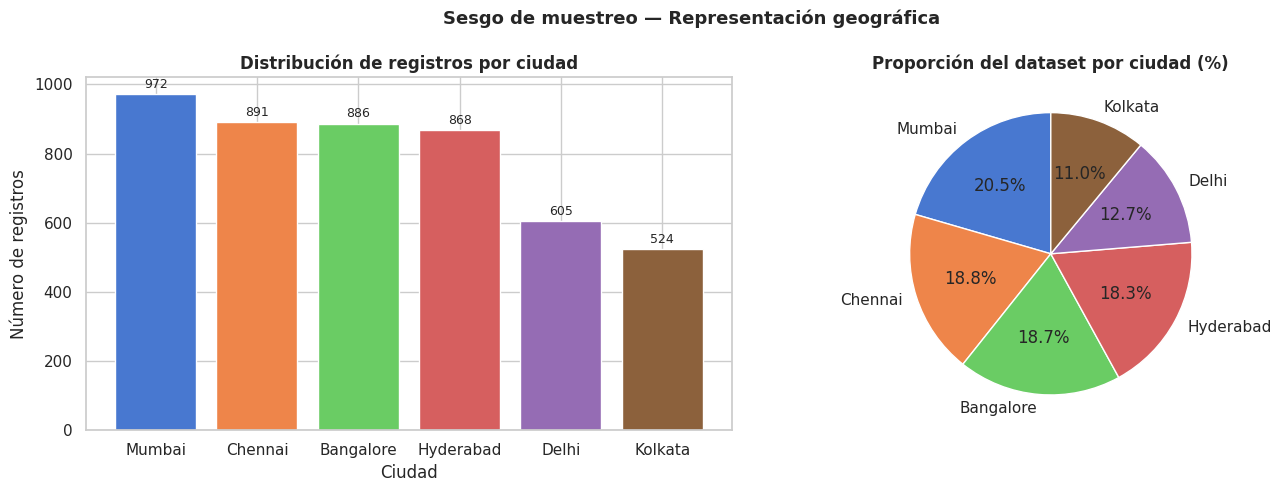


 Distribución por ciudad:
           Registros  Porcentaje (%)
City                                
Mumbai           972            20.5
Chennai          891            18.8
Bangalore        886            18.7
Hyderabad        868            18.3
Delhi            605            12.7
Kolkata          524            11.0


In [ ]:
# 1.5.2 CUANTIFICACIÓN DEL SESGO DE MUESTREO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución absoluta por ciudad
city_counts = df_raw['City'].value_counts()
bars = axes[0].bar(city_counts.index, city_counts.values,
                   color=sns.color_palette('muted', len(city_counts)),
                   edgecolor='white')
axes[0].set_title('Distribución de registros por ciudad', fontweight='bold')
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Número de registros')
for bar, val in zip(bars, city_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Distribución porcentual (evidencia el desbalance)
pct_city = (city_counts / city_counts.sum() * 100).round(1)
axes[1].pie(pct_city.values, labels=pct_city.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted', len(city_counts)))
axes[1].set_title('Proporción del dataset por ciudad (%)', fontweight='bold')

plt.suptitle('Sesgo de muestreo — Representación geográfica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen numérico
print("\n Distribución por ciudad:")
resumen_ciudad = pd.DataFrame({
    'Registros': city_counts,
    'Porcentaje (%)': pct_city
})
print(resumen_ciudad.to_string())


### Análisis:
La muestra exhibe una distribución geográfica relativamente equilibrada entre las seis ciudades evaluadas. Mumbai se posiciona como la ciudad con mayor representatividad, concentrando el 20.5% de los registros, mientras que Kolkata registra la menor participación con un 11.0%. Al evaluar la relación entre ambos extremos, se obtiene una razón de 1.9x; estadísticamente, esta proporción representa un desbalance leve en la densidad de los datos, por lo que se determina que no existe una asimetría o sesgo de selección geográfica que comprometa la representatividad de la muestra.

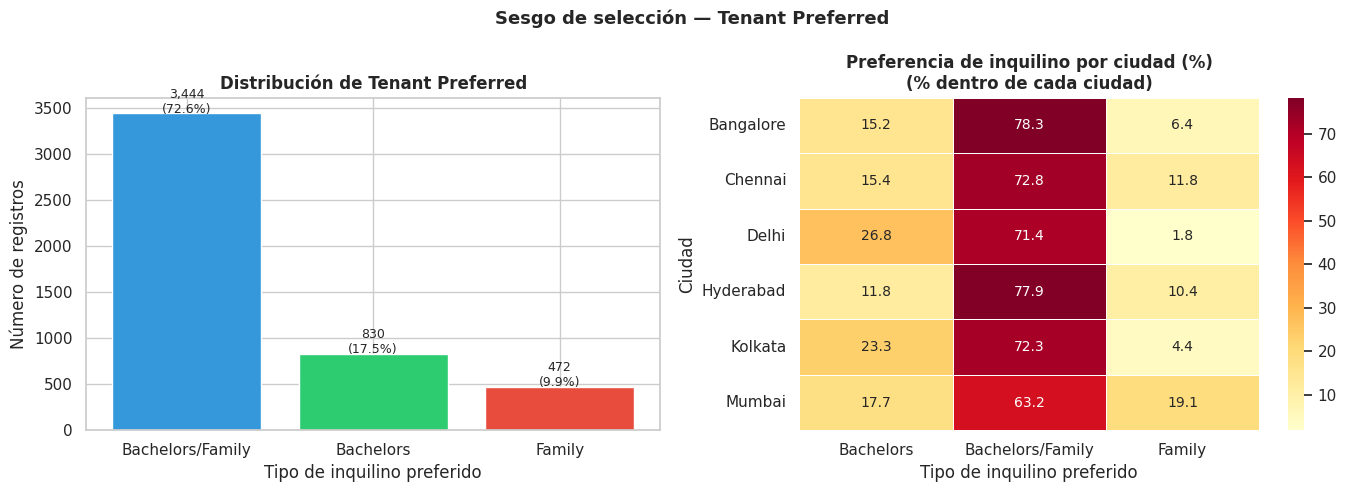

In [ ]:
# SESGO DE SELECCIÓN: Tenant Preferred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución general de Tenant Preferred
tenant_counts = df_raw['Tenant Preferred'].value_counts()
colors_tenant = ['#3498db', '#2ecc71', '#e74c3c']
axes[0].bar(tenant_counts.index, tenant_counts.values,
            color=colors_tenant, edgecolor='white')
axes[0].set_title('Distribución de Tenant Preferred', fontweight='bold')
axes[0].set_xlabel('Tipo de inquilino preferido')
axes[0].set_ylabel('Número de registros')
for i, (idx, val) in enumerate(tenant_counts.items()):
    axes[0].text(i, val + 10, f'{val:,}\n({val/len(df_raw)*100:.1f}%)',
                 ha='center', fontsize=9)

# Distribución por ciudad (heatmap de proporciones)
pivot_tenant = pd.crosstab(df_raw['City'], df_raw['Tenant Preferred'],
                            normalize='index') * 100
sns.heatmap(pivot_tenant, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, annot_kws={'size': 10})
axes[1].set_title('Preferencia de inquilino por ciudad (%)\n(% dentro de cada ciudad)',
                   fontweight='bold')
axes[1].set_xlabel('Tipo de inquilino preferido')
axes[1].set_ylabel('Ciudad')

plt.suptitle('Sesgo de selección — Tenant Preferred',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis
El conjunto de gráficos revela que la categoría dominante es la "Bachelors/Family" lo que quiere decir que la mayoría de arrendatarios no muestran interés ante un inquilino en especifico. Por su parte, el gráfico de calor demuestra que cuando se aplican restricciones, el mercado se segmenta de forma muy diferente según la región: ciudades como Dehli y Kolkata exhiben tasas de preferencia exclusiva por solteros (Bachelors) inusualmente altas (26.8% y 23.3% respectivamente), mientras que en Mumbay se inclina más hacia las familias registrando un (15.5%) pero con unos valores similares respecto a los solteros (17.7%).

### <span style="color:#1a7a4a;"><strong>1.5.3 Conclusiones éticas</strong></span>

A partir del análisis anterior, se adoptan las siguientes decisiones éticas para el desarrollo del proyecto:

| Principio | Decisión adoptada |
|---|---|
| Privacy by Design | El análisis es exclusivamente académico. No se cruzan datos con fuentes externas. |
| Sesgo de muestreo | Se reconoce que las conclusiones aplican solo a las seis ciudades representadas. |
| Sesgo de Selección | La variable `Tenant Preferred` se usa solo como descriptiva, no como variable predictiva. |
| Trazabilidad | Cada decisión metodológica queda documentada en este notebook con su justificación. |


---
## <span style="color:#2F749F;"><strong>2. Preprocesamiento inicial</strong></span>

Antes del análisis exploratorio, se realizan correcciones necesarias en los tipos de datos, se identifican duplicados y se extraen características de la variable temporal.

In [6]:
# Trabajar sobre una copia
df = df_raw.copy()

# 2.1 CONVERSIÓN DE TIPO: Posted On → datetime
df['Posted On'] = pd.to_datetime(df['Posted On'])
print("'Posted On' convertida a datetime.")
print(f"   Rango temporal: {df['Posted On'].min().date()} → {df['Posted On'].max().date()}")

# 2.2 EXTRACCIÓN DE CARACTERÍSTICAS TEMPORALES
df['Año']    = df['Posted On'].dt.year
df['Mes']    = df['Posted On'].dt.month
df['Nombre_Mes'] = df['Posted On'].dt.strftime('%b')

# 2.3 DUPLICADOS
n_dup = df.duplicated().sum()
print(f"\n Registros duplicados: {n_dup}")
if n_dup > 0:
    df = df.drop_duplicates()
    print(f"   Eliminados. Nuevo tamaño: {df.shape[0]:,}")

# 2.4 EXTRACCIÓN DE PISO (Floor)
def extraer_piso(valor):
    if pd.isnull(valor):
        return np.nan
    val_lower = str(valor).lower()
    if 'ground' in val_lower:
        return 0
    if 'basement' in val_lower or 'lower' in val_lower:
        return -1
    try:
        return int(str(valor).split(' ')[0])
    except:
        return np.nan

df['Piso_Num'] = df['Floor'].apply(extraer_piso)
print(f"\n Variable 'Piso_Num' creada.")
print(df['Piso_Num'].value_counts().head(8))

'Posted On' convertida a datetime.
   Rango temporal: 2022-04-13 → 2022-07-11

 Registros duplicados: 0

 Variable 'Piso_Num' creada.
Piso_Num
1    1161
2     945
0     927
3     512
4     272
5     164
6      93
7      74
Name: count, dtype: int64


In [7]:
# 2.5 RESUMEN DE VALORES FALTANTES
faltantes = df.isnull().sum()
pct = (faltantes / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Faltantes': faltantes, 'Porcentaje (%)': pct})
resumen_nulos = resumen_nulos[resumen_nulos['Faltantes'] > 0]

if resumen_nulos.empty:
    print("No se encontraron valores faltantes en el dataset.")
else:
    print("Variables con valores faltantes:")
    print(resumen_nulos)

No se encontraron valores faltantes en el dataset.


---
## <span style="color:#2F749F;"><strong>3. Análisis Exploratorio de Datos (EDA)</strong></span>

El EDA sigue tres niveles progresivos: **univariado**, **bivariado** y **multivariado** ). En cada sección se interpretan los resultados en función de la pregunta de investigación.

### <span style="color:#1a7a4a;"><strong>3.1 Análisis Univariado</strong></span>
**Objetivo:** Describir la distribución individual de las variables más relevantes para la pregunta de investigación. Se seleccionan `Rent` como variable objetivo, `Size`, `BHK` y `Bathroom` por ser las características físicas principales del inmueble, y `City` y `Furnishing Status` por ser los factores contextuales con mayor capacidad esperada de diferenciación de precios según la literatura de mercados inmobiliarios. Variables como `Area Locality` y `Point of Contact` se excluyen del análisis univariado por su alta cardinalidad o nula relevancia analítica para la pregunta planteada.

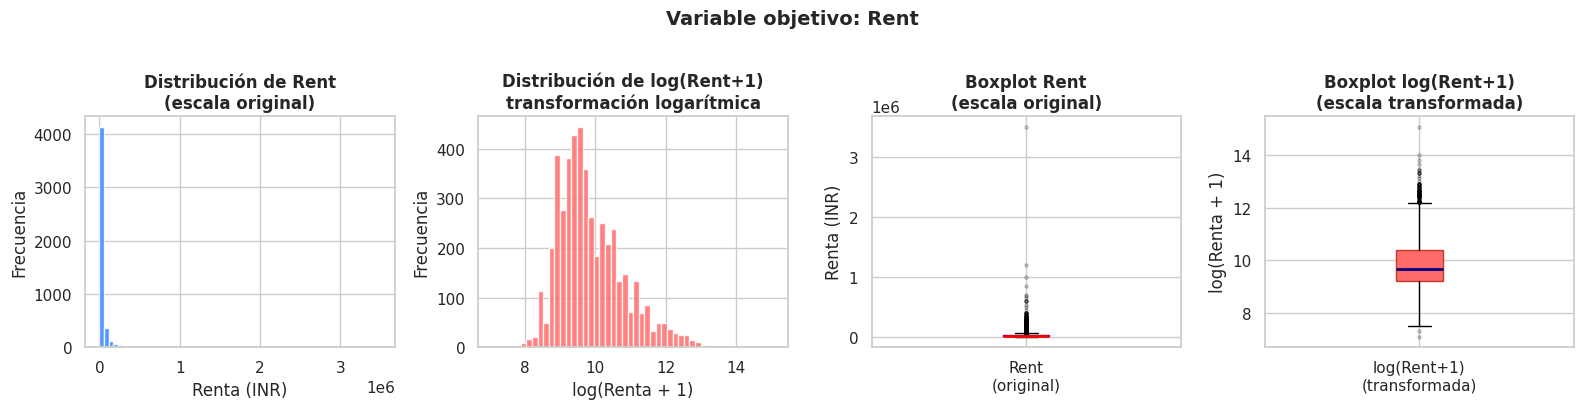


 Estadísticas descriptivas de Rent:
count        4,746
mean        34,993
std         78,106
min          1,200
25%         10,000
50%         16,000
75%         33,000
max      3,500,000
Name: Rent, dtype: object

Asimetría (skewness): 21.410
Curtosis (kurtosis):  841.108


In [15]:
# VARIABLE OBJETIVO: Rent
fig = plt.figure(figsize=(16, 4))

# Subplot 1: histograma original
ax1 = fig.add_subplot(1, 4, 1)
ax1.hist(df['Rent'], bins=60, color='#3a86ff',
         edgecolor='white', alpha=0.85)
ax1.set_title('Distribución de Rent\n(escala original)', fontweight='bold')
ax1.set_xlabel('Renta (INR)')
ax1.set_ylabel('Frecuencia')

# Subplot 2: histograma transformado
ax2 = fig.add_subplot(1, 4, 2)
ax2.hist(np.log1p(df['Rent']), bins=50, color='#ff6b6b',
         edgecolor='white', alpha=0.85)
ax2.set_title('Distribución de log(Rent+1)\ntransformación logarítmica',
              fontweight='bold')
ax2.set_xlabel('log(Renta + 1)')
ax2.set_ylabel('Frecuencia')

# Subplot 3: boxplot Rent original (su propia escala)
ax3 = fig.add_subplot(1, 4, 3)
ax3.boxplot(df['Rent'], patch_artist=True,
            boxprops=dict(facecolor='#8ecae6', color='navy'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=2,
                            alpha=0.3, color='gray'))
ax3.set_title('Boxplot Rent\n(escala original)', fontweight='bold')
ax3.set_ylabel('Renta (INR)')
ax3.set_xticks([1])
ax3.set_xticklabels(['Rent\n(original)'])

# Subplot 4: boxplot log(Rent+1) (su propia escala)
ax4 = fig.add_subplot(1, 4, 4)
ax4.boxplot(np.log1p(df['Rent']), patch_artist=True,
            boxprops=dict(facecolor='#ff6b6b', color='#c0392b'),
            medianprops=dict(color='navy', linewidth=2),
            flierprops=dict(marker='o', markersize=2,
                            alpha=0.3, color='gray'))
ax4.set_title('Boxplot log(Rent+1)\n(escala transformada)', fontweight='bold')
ax4.set_ylabel('log(Renta + 1)')
ax4.set_xticks([1])
ax4.set_xticklabels(['log(Rent+1)\n(transformada)'])

plt.suptitle('Variable objetivo: Rent', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# Estadísticas descriptivas
print("\n Estadísticas descriptivas de Rent:")
print(df['Rent'].describe().apply(lambda x: f"{x:,.0f}"))
print(f"\nAsimetría (skewness): {df['Rent'].skew():.3f}")
print(f"Curtosis (kurtosis):  {df['Rent'].kurtosis():.3f}")


### Análisis:

La variable Rent presenta una distribución fuertemente asimétrica (skewness = 21.41), donde la gran mayoría de propiedades se concentra entre 10.000 y 33.000 INR, pero un pequeño grupo de inmuebles de lujo alcanza los 3.500.000 INR, generando una cola derecha que hace ilegible la distribución en escala original.

Para corregir este comportamiento se aplicó la transformación log(x + 1) sobre cada valor de renta. Esta función reduce el sesgo al comprimir los valores extremos: la diferencia entre 16.000 y 3.500.000 INR, que en escala original es de más de 3,4 millones de unidades, queda reducida a apenas 5,4 unidades en escala logarítmica. El resultado es una reducción del coeficiente de asimetría de 21.41 a 0.91

El boxplot comparativo evidencia el efecto de esta transformación sobre la estructura interna del dato: en la escala original la caja es prácticamente invisible frente a los valores extremos, mientras que en la escala transformada los cuartiles son legibles y la mediana queda correctamente posicionada. Ambas distribuciones conservan outliers, confirmando que los valores atípicos son propiedades de lujo reales y no errores de captura.

In [ ]:
# TEST DE NORMALIDAD PARA Rent
np.random.seed(42)
muestra = df['Rent'].dropna().sample(500)

stat_ks, p_ks = kstest(muestra, 'norm',
                        args=(muestra.mean(), muestra.std()))

stat_sw, p_sw = shapiro(muestra)

print("="*55)
print("  Test de normalidad sobre Rent (muestra n=500)")
print("="*55)
print(f"  Kolmogorov-Smirnov : estadístico={stat_ks:.4f}, p={p_ks:.4e}")
print(f"  Shapiro-Wilk        : estadístico={stat_sw:.4f}, p={p_sw:.4e}")
print("="*55)


  Test de normalidad sobre Rent (muestra n=500)
  Kolmogorov-Smirnov : estadístico=0.3229, p=6.8764e-47
  Shapiro-Wilk        : estadístico=0.3722, p=3.4462e-38


### Análisis
Los resultados de ambas pruebas rechazan la hipótesis nula de normalidad con p-valores extremadamente pequeños (KS: 6.87e-47, SW: 3.45e-38), lo que era esperable dado el comportamiento visual observado en el histograma. La distribución de `Rent` presenta una asimetría positiva marcada, característica típica de variables de precio donde unos pocos valores extremos (las propiedades de lujo) jalan la cola hacia la derecha. Esta conclusión justifica el uso de la transformación logarítmica en los análisis subsiguientes y el uso de Spearman en lugar de Pearson para las correlaciones.

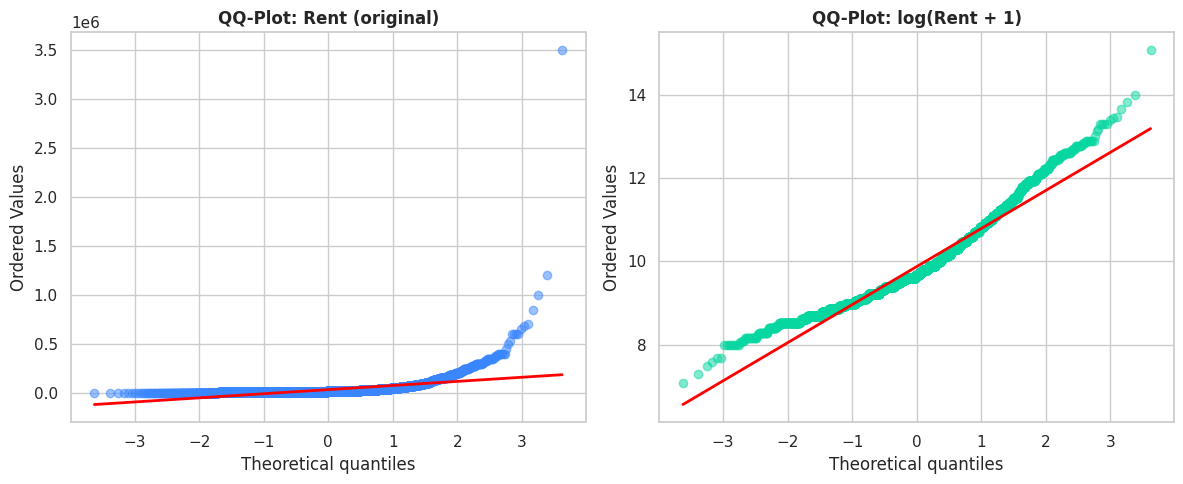


El QQ-plot confirma la fuerte desviación de normalidad en escala original.
   La transformación logarítmica acerca la distribución a la normal.


In [ ]:
#QQ-PLOT para confirmar asimetría
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# QQ-plot Rent original
stats.probplot(df['Rent'].dropna(), dist='norm', plot=axes[0])
axes[0].set_title('QQ-Plot: Rent (original)', fontweight='bold')
axes[0].get_lines()[0].set(color='#3a86ff', alpha=0.5)
axes[0].get_lines()[1].set(color='red', linewidth=2)

# QQ-plot log(Rent)
stats.probplot(np.log1p(df['Rent'].dropna()), dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot: log(Rent + 1)', fontweight='bold')
axes[1].get_lines()[0].set(color='#06d6a0', alpha=0.5)
axes[1].get_lines()[1].set(color='red', linewidth=2)

plt.tight_layout()
plt.show()
print("\nEl QQ-plot confirma la fuerte desviación de normalidad en escala original.")
print("   La transformación logarítmica acerca la distribución a la normal.")


Size:
   Media: 967.49 | Mediana: 850.00 | Skewness: 2.300

BHK:
   Media: 2.08 | Mediana: 2.00 | Skewness: 0.599

Bathroom:
   Media: 1.97 | Mediana: 2.00 | Skewness: 1.273


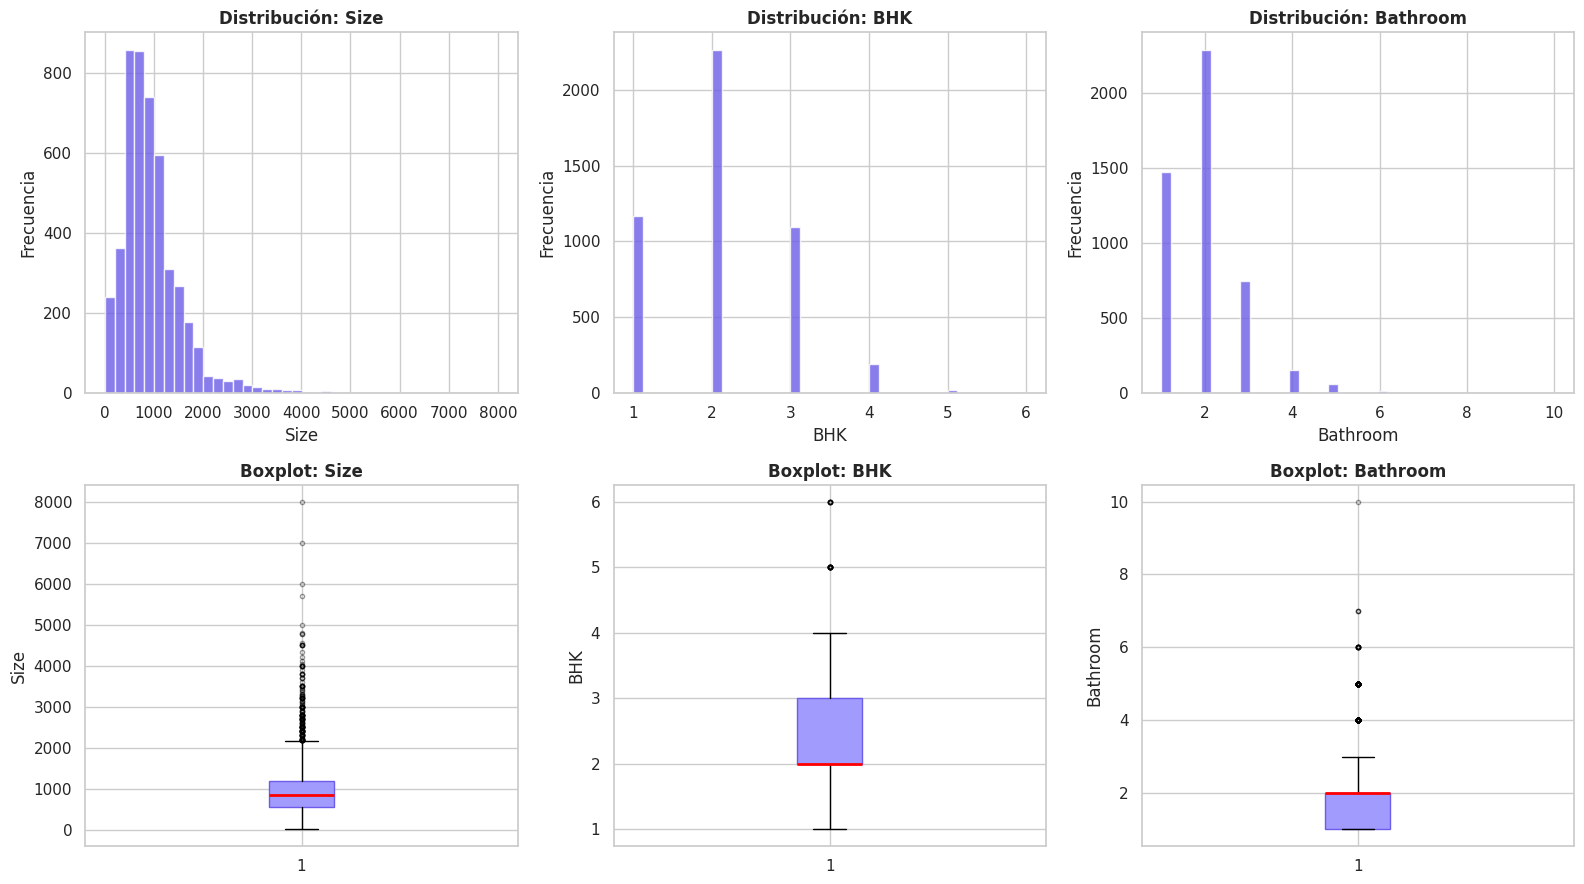

In [ ]:
# VARIABLES NUMÉRICAS: Size, BHK, Bathroom
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
vars_num = ['Size', 'BHK', 'Bathroom']

for i, var in enumerate(vars_num):
    data = df[var].dropna()

    # Histograma
    axes[0, i].hist(data, bins=40, color='#6c5ce7', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'Distribución: {var}', fontweight='bold')
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel('Frecuencia')

    # Boxplot
    axes[1, i].boxplot(data, patch_artist=True,
                       boxprops=dict(facecolor='#a29bfe', color='#6c5ce7'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', color='#fd79a8', alpha=0.4, markersize=3))
    axes[1, i].set_title(f'Boxplot: {var}', fontweight='bold')
    axes[1, i].set_ylabel(var)

    # Estadísticas en consola
    print(f"\n{var}:")
    print(f"   Media: {data.mean():.2f} | Mediana: {data.median():.2f} | "
          f"Skewness: {data.skew():.3f}")

plt.tight_layout()
plt.show()

### Análisis
 `BHK` y `Bathroom` muestran un estándar consolidado: la mayoría de propiedades tienen 2 habitaciones y 2 baños, con caída rápida hacia configuraciones de lujo. `Size` en cambio presenta fuerte asimetría positiva — la mayoría de inmuebles se concentra entre 500 y 1.200 pies cuadrados (mediana: 850 aprox), pero una cola de valores extremos se extiende hasta los 8.000 pies cuadrados, correspondiente a residencias excepcionales. Este comportamiento justifica la aplicación de la transformación logarítmica (`log_Size`) en los análisis posteriores para estabilizar la varianza.

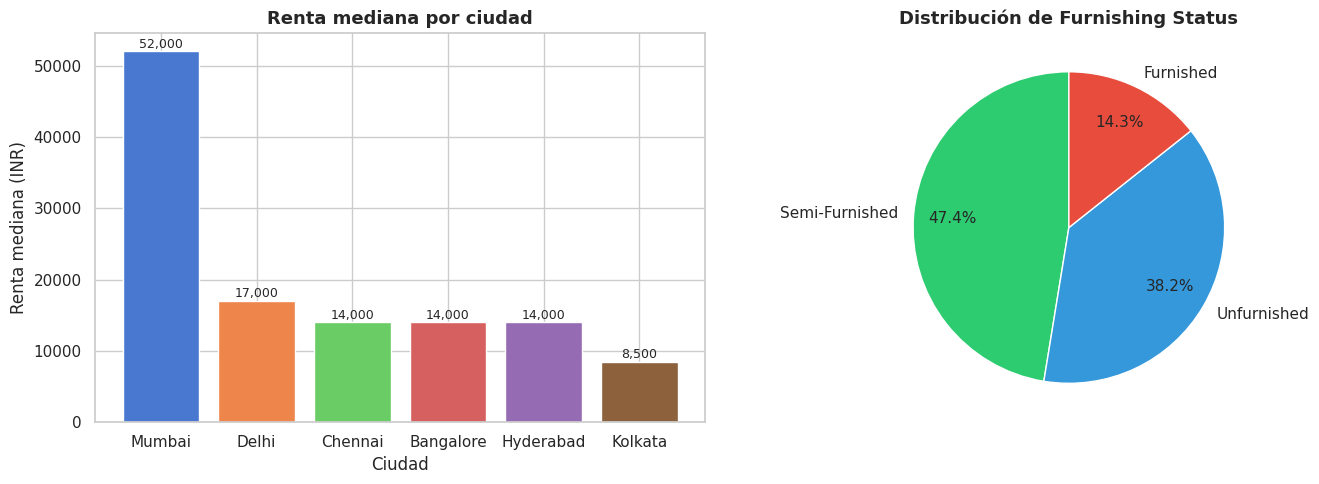


Renta mediana por ciudad (INR):
City
Mumbai       52,000
Delhi        17,000
Chennai      14,000
Bangalore    14,000
Hyderabad    14,000
Kolkata       8,500

Frecuencias — Furnishing Status:
Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680


In [ ]:
# ── VARIABLES CATEGÓRICAS: Rent mediana por Ciudad y Furnishing Status ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rent mediano por ciudad
rent_ciudad = df.groupby('City')['Rent'].median().sort_values(ascending=False)
bars = axes[0].bar(rent_ciudad.index, rent_ciudad.values,
                   color=sns.color_palette('muted', len(rent_ciudad)), edgecolor='white')
axes[0].set_title('Renta mediana por ciudad', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Renta mediana (INR)')
for bar, val in zip(bars, rent_ciudad.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

# Furnishing Status
furn_counts = df['Furnishing Status'].value_counts()
colors_furn = ['#2ecc71', '#3498db', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(furn_counts.values, labels=furn_counts.index,
                                        autopct='%1.1f%%', colors=colors_furn,
                                        startangle=90, pctdistance=0.75)
for at in autotexts:
    at.set_fontsize(11)
axes[1].set_title('Distribución de Furnishing Status', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print("\nRenta mediana por ciudad (INR):")
print(rent_ciudad.apply(lambda x: f"{x:,.0f}").to_string())
print("\nFrecuencias — Furnishing Status:")
print(furn_counts.to_string())

### Análisis
La renta mediana por ciudad expone una brecha extraordinaria entre mercados: Mumbai lidera con 52.000 INR, más del triple que Delhi (17.000 INR) y casi seis veces por encima de Kolkata (8.500 INR), lo que refleja la presión inmobiliaria característica de la capital financiera de India. Chennai, Bangalore e Hyderabad convergen en 14.000 INR, sugiriendo dinámicas de mercado similares. Respecto al amueblado, el mercado se inclina hacia opciones Semi-Furnished (47.4%) y Unfurnished (38.2%), siendo las propiedades Furnished una minoría del 14.3% — lo que anticipa que el nivel de amueblado podría ser un diferenciador.

### <span style="color:#1a7a4a;"><strong>3.2 Análisis Bivariado</strong></span>
**Objetivo:** Cuantificar y visualizar la relación entre el precio de renta y cada una de las variables explicativas, usando el método de correlación adecuado para cada tipo de par de variables.

In [ ]:
# 3.2.1 CORRELACIÓN Pearson y Spearman: Rent vs numéricas
vars_num_analisis = ['Size', 'BHK', 'Bathroom']

print("="*65)
print(f"  {'Variable':<15} {'Pearson r':>12} {'p-valor':>12} {'Spearman ρ':>12} {'p-valor':>12}")
print("="*65)
for var in vars_num_analisis:
    sub = df[['Rent', var]].dropna()
    r_p, p_p = pearsonr(sub['Rent'], sub[var])
    r_s, p_s = spearmanr(sub['Rent'], sub[var])
    print(f"  {var:<15} {r_p:>12.4f} {p_p:>12.4e} {r_s:>12.4f} {p_s:>12.4e}")
print("="*65)
print("\n Spearman es más apropiado dado que Rent no es normal.")
print("   Un p-valor < 0.05 indica correlación estadísticamente significativa.")

  Variable           Pearson r      p-valor   Spearman ρ      p-valor
  Size                  0.4136  1.6909e-195       0.5214   0.0000e+00
  BHK                   0.3697  1.2069e-153       0.5684   0.0000e+00
  Bathroom              0.4412  2.4419e-225       0.6630   0.0000e+00

 Spearman es más apropiado dado que Rent no es normal.
   Un p-valor < 0.05 indica correlación estadísticamente significativa.


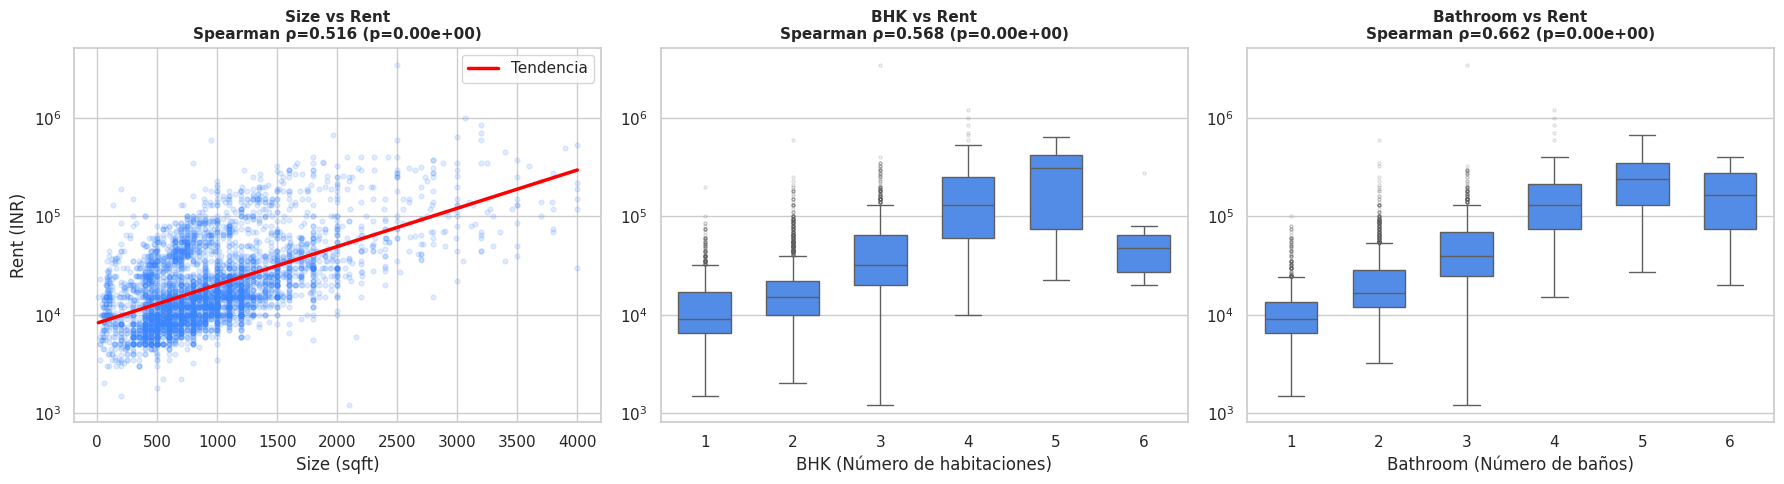

In [ ]:
# Visualización: Scatterplots Rent vs numéricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

var_1 = 'Size'
sub_1 = df[[var_1, 'Rent']].dropna()

sub_1 = sub_1[sub_1[var_1] <= 4000]

axes[0].scatter(sub_1[var_1], sub_1['Rent'], alpha=0.15, s=12, color='#3a86ff')

z = np.polyfit(sub_1[var_1], np.log(sub_1['Rent']), 1)
p = np.poly1d(z)
xline = np.linspace(sub_1[var_1].min(), sub_1[var_1].max(), 100)
axes[0].plot(xline, np.exp(p(xline)), color='red', linewidth=2.5, label='Tendencia')

r_s, p_s = spearmanr(sub_1[var_1], sub_1['Rent'])
axes[0].set_title(f'{var_1} vs Rent\nSpearman ρ={r_s:.3f} (p={p_s:.2e})', fontweight='bold', fontsize=11)
axes[0].set_xlabel(f'{var_1} (sqft)')
axes[0].set_ylabel('Rent (INR)')
axes[0].set_yscale('log')
axes[0].legend()

var_2 = 'BHK'
sub_2 = df[[var_2, 'Rent']].dropna()
sub_2 = sub_2[sub_2[var_2] <= 6]
sub_2['BHK'] = sub_2['BHK'].astype(int)


sns.boxplot(data=sub_2, x=var_2, y='Rent', ax=axes[1], color='#3a86ff', width=0.6, flierprops={'markersize': 2, 'alpha': 0.2})

r_s, p_s = spearmanr(sub_2[var_2], sub_2['Rent'])
axes[1].set_title(f'{var_2} vs Rent\nSpearman ρ={r_s:.3f} (p={p_s:.2e})', fontweight='bold', fontsize=11)
axes[1].set_xlabel('BHK (Número de habitaciones)')
axes[1].set_ylabel('')
axes[1].set_yscale('log')

var_3 = 'Bathroom'
sub_3 = df[[var_3, 'Rent']].dropna()
sub_3 = sub_3[sub_3[var_3] <= 6]

sns.boxplot(data=sub_3, x=var_3, y='Rent', ax=axes[2], color='#3a86ff', width=0.6, flierprops={'markersize': 2, 'alpha': 0.2})

r_s, p_s = spearmanr(sub_3[var_3], sub_3['Rent'])
axes[2].set_title(f'{var_3} vs Rent\nSpearman ρ={r_s:.3f} (p={p_s:.2e})', fontweight='bold', fontsize=11)
axes[2].set_xlabel('Bathroom (Número de baños)')
axes[2].set_ylabel('')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

### Análisis
Las tres variables físicas presentan correlación positiva y estadísticamente significativa con `Rent` (p ≈ 0.00). `Bathroom` es el predictor individual más robusto (ρ = 0.662), seguido de `BHK` (ρ = 0.568) y `Size` (ρ = 0.516). Los gráficos de `BHK` y `Bathroom` muestran un comportamiento escalonado donde la renta mediana se duplica o triplica con cada unidad adicional, aunque ambas variables presentan una caída anómala en la categoría de 6 unidades explicable por escasez muestral en el extremo superior. La dispersión en `Size vs Rent` refleja la influencia de factores externos como la ubicación, lo que anticipa la necesidad de un análisis multivariado para capturar estas interacciones.

In [ ]:
# 3.2.2 PRUEBA KRUSKAL-WALLIS: Rent vs categóricas
vars_cat = ['City', 'Furnishing Status', 'Tenant Preferred']

print("="*60)
print(f"  {'Variable':<22} {'H-estadístico':>16} {'p-valor':>12}")
print("="*60)
for var in vars_cat:
    grupos = [group['Rent'].values for _, group in df.groupby(var)]
    h_stat, p_val = kruskal(*grupos)
    significativo = "Significativo" if p_val < 0.05 else " No significativo"
    print(f"  {var:<22} {h_stat:>16.3f} {p_val:>12.4e}  {significativo}")
print("="*60)
print("\n Un p < 0.05 indica que la variable categórica influye en el precio de renta.")

  Variable                  H-estadístico      p-valor
  City                           1613.674   0.0000e+00  Significativo
  Furnishing Status               423.495   1.0948e-92  Significativo
  Tenant Preferred                177.237   3.2612e-39  Significativo

 Un p < 0.05 indica que la variable categórica influye en el precio de renta.


### Análisis
Las tres variables categóricas muestran un efecto estadísticamente significativo sobre `Rent` (p < 0.05 en todos los casos). `City` presenta el estadístico H más alto (1613.674), lo que indica que la ubicación geográfica es el factor categórico con mayor capacidad diferenciadora del precio — consistente con la brecha de 6x observada entre Mumbai y Kolkata en el análisis univariado. `Furnishing Status` ocupa el segundo lugar (H = 423.495), confirmando que el nivel de amueblado tiene un impacto real y no aleatorio sobre el precio. `Tenant Preferred` aunque significativo, registra el H más bajo (177.237), sugiriendo que su influencia sobre el precio es menor comparada con las otras dos variables — lo que refuerza la decisión ética de tratarla como variable descriptiva y no predictiva.

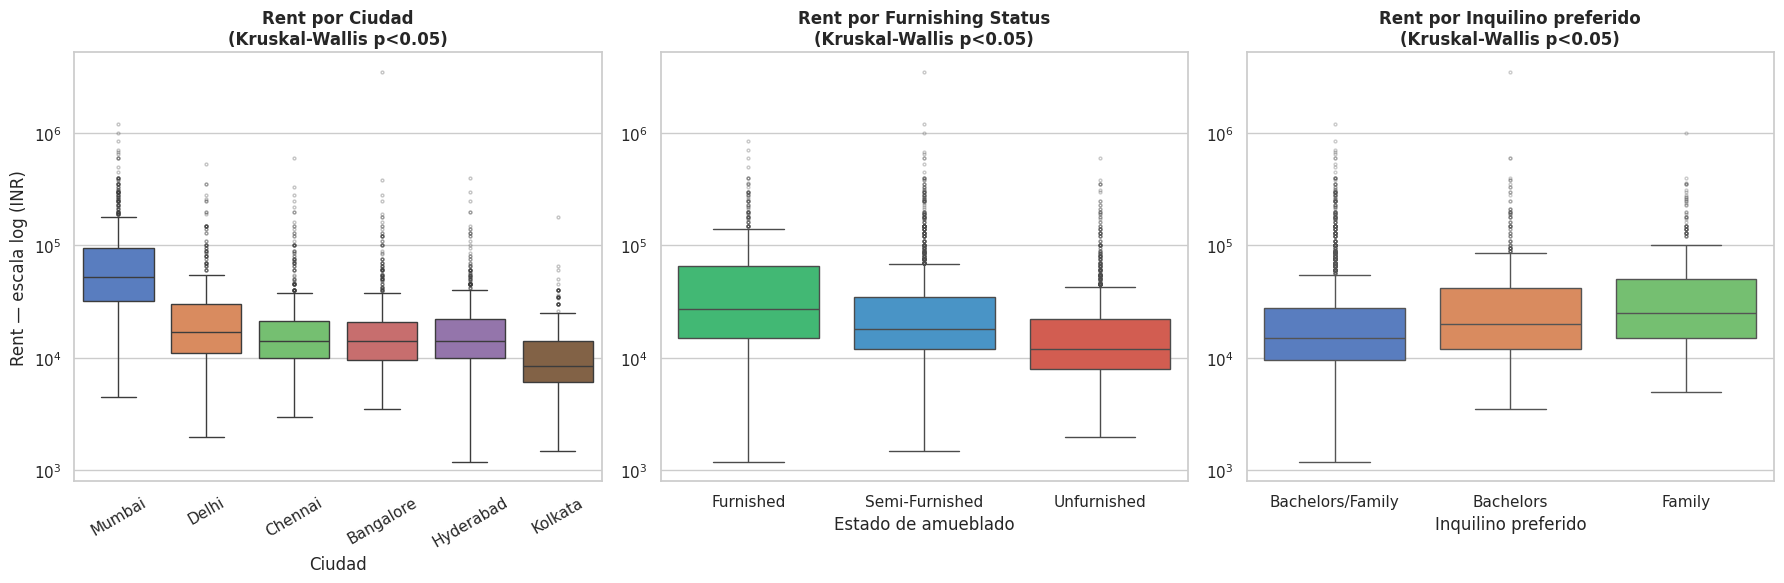

In [ ]:
# Boxplots: Rent vs categóricas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = sns.color_palette('muted', 10)

# Ciudad
order_city = df.groupby('City')['Rent'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='City', y='Rent', order=order_city,
            palette=palette[:6], ax=axes[0], flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_yscale('log')
axes[0].set_title('Rent por Ciudad\n(Kruskal-Wallis p<0.05)', fontweight='bold')
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Rent — escala log (INR)')
axes[0].tick_params(axis='x', rotation=30)

# Furnishing Status
order_furn = ['Furnished', 'Semi-Furnished', 'Unfurnished']
sns.boxplot(data=df, x='Furnishing Status', y='Rent', order=order_furn,
            palette=['#2ecc71','#3498db','#e74c3c'], ax=axes[1],
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_yscale('log')
axes[1].set_title('Rent por Furnishing Status\n(Kruskal-Wallis p<0.05)', fontweight='bold')
axes[1].set_xlabel('Estado de amueblado')
axes[1].set_ylabel('')

# Tenant Preferred
sns.boxplot(data=df, x='Tenant Preferred', y='Rent',
            palette=palette[:3], ax=axes[2],
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[2].set_yscale('log')
axes[2].set_title('Rent por Inquilino preferido\n(Kruskal-Wallis p<0.05)', fontweight='bold')
axes[2].set_xlabel('Inquilino preferido')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### Análisis
Los boxplots confirman visualmente lo que Kruskal-Wallis indicó estadísticamente. La ciudad es el factor más disruptivo: Mumbai lidera con una mediana de 50.000 INR, superando incluso los terceros cuartiles de las demás ciudades, mientras Kolkata representa el mercado más económico con una mediana inferior a 10.000 INR. El amueblado sigue una jerarquía lineal descendente — Furnished (~ 25.000 INR), Semi-Furnished (~ 18.000 INR) y Unfurnished (~12.000 INR) — lo que sugiere que cada escalón de amueblado representa un segmento de mercado diferenciado. Finalmente, `Tenant Preferred` revela una prima por estabilidad: los contratos exclusivos para Family alcanzan medianas de ~25.000 INR frente a ~15.000 INR de las opciones flexibles, aunque la amplia superposición entre categorías indica que esta variable actúa como modulador secundario del precio, no como determinante principal.

In [ ]:
# 3.2.3 CHI-CUADRADO: relación entre categóricas
# ¿La ciudad está asociada con el estado de amueblado?
tabla_contingencia = pd.crosstab(df['City'], df['Furnishing Status'])
chi2, p_chi, dof, expected = chi2_contingency(tabla_contingencia)

print("="*55)
print("  Chi-cuadrado: City vs Furnishing Status")
print("="*55)
print(f"  Chi² = {chi2:.4f} | gl = {dof} | p = {p_chi:.4e}")
if p_chi < 0.05:
    print("Existe asociación significativa entre ciudad y amueblado.")
else:
    print("No se evidencia asociación significativa.")
print()
print("Tabla de contingencia (frecuencias observadas):")
print(tabla_contingencia.to_string())

  Chi-cuadrado: City vs Furnishing Status
  Chi² = 351.5571 | gl = 10 | p = 1.8618e-69
Existe asociación significativa entre ciudad y amueblado.

Tabla de contingencia (frecuencias observadas):
Furnishing Status  Furnished  Semi-Furnished  Unfurnished
City                                                     
Bangalore                 91             584          211
Chennai                   81             448          362
Delhi                     97             278          230
Hyderabad                111             402          355
Kolkata                   61             142          321
Mumbai                   239             397          336


### <span style="color:#1a7a4a;"><strong>3.3 Análisis Multivariado</strong></span>
**Objetivo:** Explorar las relaciones simultáneas entre múltiples variables para identificar patrones de agrupación, interacciones y la estructura latente de los datos.

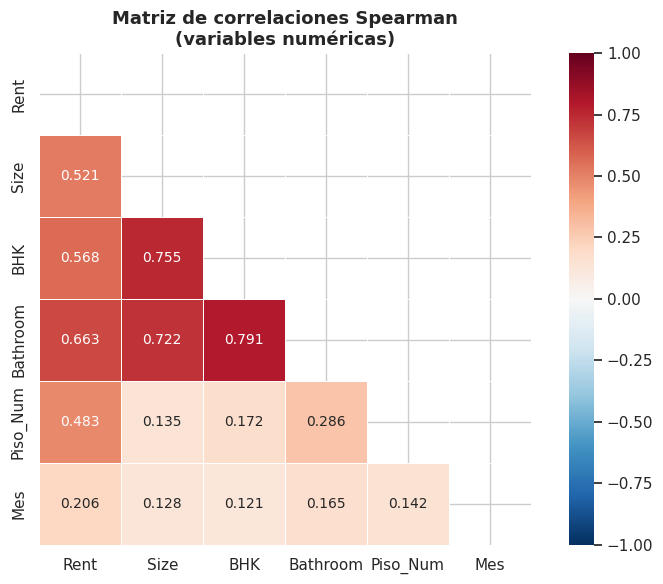

In [ ]:
# 3.3.1 MAPA DE CORRELACIONES (Spearman)
vars_num_corr = ['Rent', 'Size', 'BHK', 'Bathroom', 'Piso_Num', 'Mes']
corr_matrix = df[vars_num_corr].dropna().corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask,
            ax=ax, linewidths=0.5, square=True,
            annot_kws={'size': 10})
ax.set_title('Matriz de correlaciones Spearman\n(variables numéricas)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Análisis
La matriz de Spearman revela que `Bathroom` (ρ = 0.663), `BHK` (ρ = 0.578) y `Size` (ρ = 0.536) son los predictores más asociados con `Rent`, mientras `Piso_Num` muestra una correlación moderada (ρ = 0.483) y `Mes` resulta prácticamente irrelevante (ρ < 0.21), descartando cualquier estacionalidad en el precio. El hallazgo más importante es la multicolinealidad entre las variables estructurales: `BHK`, `Bathroom` y `Size` presentan correlaciones cruzadas entre 0.721 y 0.776, indicando que comparten gran parte de su varianza explicativa. Esto implica que en etapas de modelado no deberían incluirse las tres simultáneamente sin un tratamiento previo — como PCA o selección de variables — para evitar redundancia informativa.

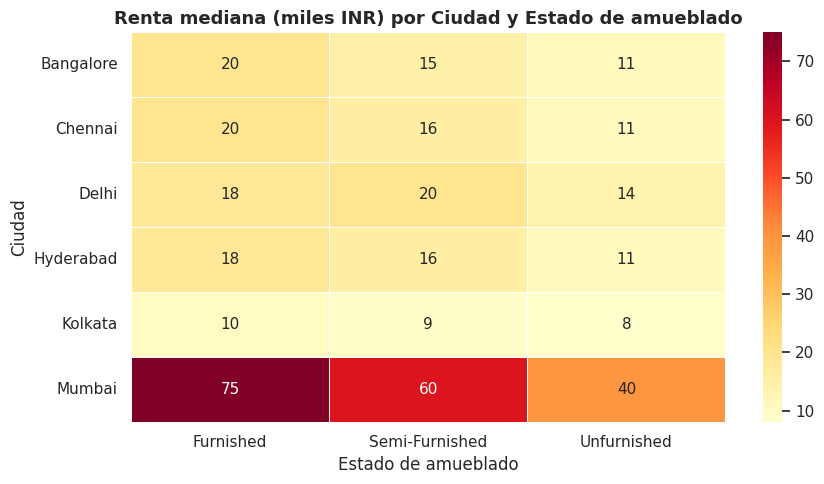

In [ ]:
#3.3.2 PRECIO PROMEDIO POR CIUDAD Y AMUEBLADO (Heatmap)
pivot = df.groupby(['City', 'Furnishing Status'])['Rent'].median().unstack()
pivot = pivot.reindex(columns=['Furnished', 'Semi-Furnished', 'Unfurnished'])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot/1000, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=ax, linewidths=0.5,
            annot_kws={'size': 11})
ax.set_title('Renta mediana (miles INR) por Ciudad y Estado de amueblado',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Estado de amueblado')
ax.set_ylabel('Ciudad')
plt.tight_layout()
plt.show()


### Análisis
Se realizaron dos hallazgos clave. Primero, Mumbai opera en una escala de precios completamente aislada: su renta mediana Unfurnished (40.000 INR) supera la opción Furnished de prácticamente cualquier otra ciudad, confirmando que la ubicación geográfica supera al amueblado como determinante del precio. Segundo, la prima por amueblado no es uniforme — en Kolkata la diferencia entre Unfurnished y Furnished es de apenas 2.000 INR, mientras que en Mumbai escala a 35.000 INR, lo que indica que el retorno de inversión por equipamiento interno está directamente condicionado a la plusvalía del mercado local. El resto de ciudades (Bangalore, Chennai, Delhi, Hyderabad, Kolkata) convergen en un rango estrecho de 8.000 a 20.000 INR independientemente del amueblado, sugiriendo que en mercados menos premium la ubicación y el amueblado tienen un efecto combinado pero moderado sobre el precio.

Varianza explicada por componente:
   PC1: 0.696 (69.6%) — acumulado: 69.6%
   PC2: 0.181 (18.1%) — acumulado: 87.7%
   PC3: 0.074 (7.4%) — acumulado: 95.0%
   PC4: 0.050 (5.0%) — acumulado: 100.0%


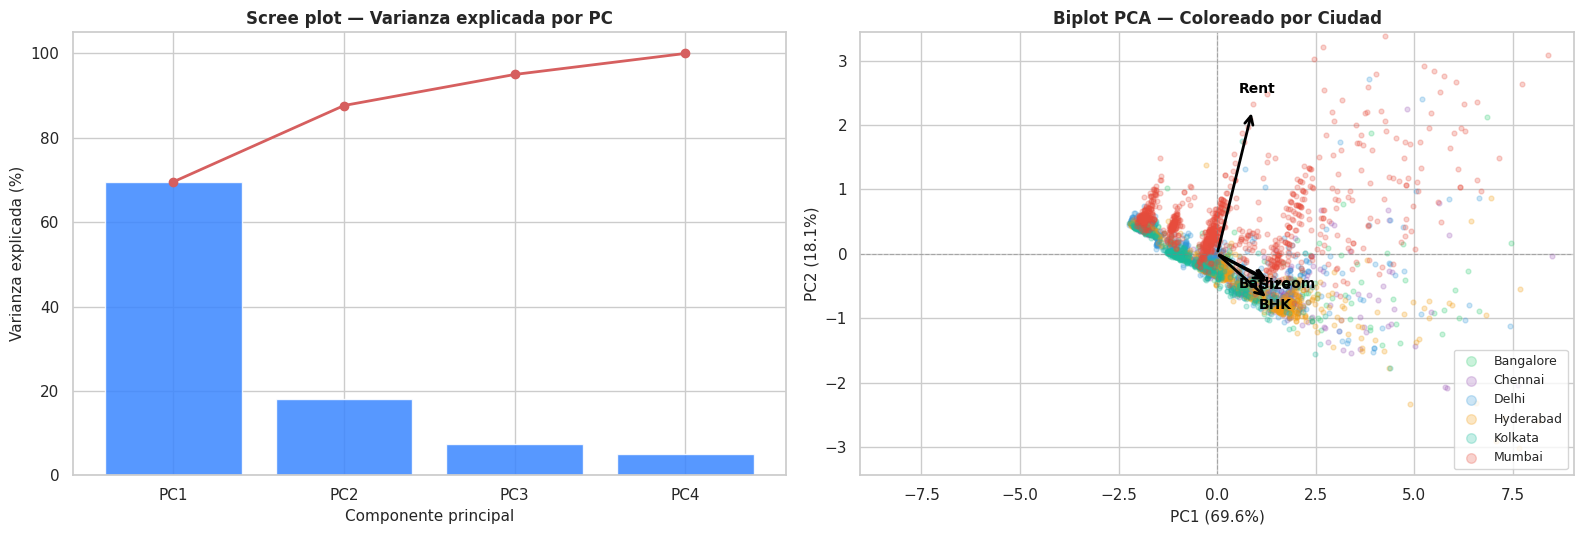

In [ ]:
# 3.3.3 ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)
vars_pca = ['Rent', 'Size', 'BHK', 'Bathroom']
df_pca = df[vars_pca + ['City', 'Furnishing Status']].dropna().reset_index(drop=True)

# 1. Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[vars_pca])

# 2. Aplicar PCA
pca = PCA(n_components=4)
componentes = pca.fit_transform(X_scaled)
varianza_explicada = pca.explained_variance_ratio_

print("Varianza explicada por componente:")
for i, v in enumerate(varianza_explicada):
    print(f"   PC{i+1}: {v:.3f} ({v*100:.1f}%) — acumulado: {sum(varianza_explicada[:i+1])*100:.1f}%")

df_comp = pd.DataFrame(componentes, columns=[f'PC{i}' for i in range(1, 5)])
df_comp['City'] = df_pca['City']

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].bar(range(1, 5), varianza_explicada*100, color='#3a86ff', edgecolor='white', alpha=0.85)
axes[0].plot(range(1, 5), np.cumsum(varianza_explicada)*100, 'ro-', linewidth=2, markersize=6)
axes[0].set_xlabel('Componente principal', fontsize=11)
axes[0].set_ylabel('Varianza explicada (%)', fontsize=11)
axes[0].set_title('Scree plot — Varianza explicada por PC', fontweight='bold', fontsize=12)
axes[0].set_xticks(range(1, 5))
axes[0].set_xticklabels([f'PC{i}' for i in range(1, 5)])

city_colors = {'Mumbai':'#e74c3c', 'Delhi':'#3498db', 'Bangalore':'#2ecc71',
               'Hyderabad':'#f39c12', 'Chennai':'#9b59b6', 'Kolkata':'#1abc9c'}

# Graficar los puntos de forma segura agrupando el nuevo DataFrame
for city, grp in df_comp.groupby('City'):
    axes[1].scatter(grp['PC1'], grp['PC2'], alpha=0.25, s=12,
                    label=city, color=city_colors.get(city, 'gray'))

x_max = np.percentile(np.abs(df_comp['PC1']), 99.5) * 1.3
y_max = np.percentile(np.abs(df_comp['PC2']), 99.5) * 1.3
axes[1].set_xlim(-x_max, x_max)
axes[1].set_ylim(-y_max, y_max)

axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

arrow_scale = min(x_max, y_max) * 0.7

loadings = pca.components_.T
for j, var in enumerate(vars_pca):
    x_arrow = loadings[j, 0] * arrow_scale
    y_arrow = loadings[j, 1] * arrow_scale

    axes[1].annotate('', xy=(x_arrow, y_arrow), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='black', lw=2, mutation_scale=15))

    axes[1].text(x_arrow * 1.15, y_arrow * 1.15, var, fontsize=10, fontweight='bold',
                 color='black', ha='center', va='center')

axes[1].set_xlabel(f'PC1 ({varianza_explicada[0]*100:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({varianza_explicada[1]*100:.1f}%)', fontsize=11)
axes[1].set_title('Biplot PCA — Coloreado por Ciudad', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right', fontsize=9, markerscale=2, frameon=True)

plt.tight_layout()
plt.show()


### Análisis
El scree plot confirma una reducción dimensional eficiente: PC1 captura el 69.4% de la varianza total y PC2 el 18.0%, acumulando entre ambos el 87.4% de la información contenida en las cuatro variables originales. PC3 y PC4 pueden descartarse sin pérdida significativa de información.

El biplot da más interpretación a estos componentes. Los vectores de `Size`, `BHK` y `Bathroom` apuntan de forma casi paralela sobre el eje horizontal, definiendo PC1 como la **dimensión estructural de la vivienda** — a mayor PC1, más grande e infraestructurada es la propiedad. El vector de `Rent` se proyecta de forma casi ortogonal sobre PC2, definiéndolo como la **dimensión del costo neto**, con una dinámica parcialmente independiente del tamaño físico — lo que confirma multivariadamente lo observado en la matriz de Spearman.

La distribución geográfica de los puntos ratifica la estratificación del mercado: Kolkata, Chennai e Hyderabad se agrupan densamente hacia valores bajos de PC1 y PC2, mientras Mumbai se despliega hacia los cuadrantes de alta infraestructura y alto costo, consolidándose como el mercado más atípico del estudio.

---
## <span style="color:#2F749F;"><strong>4. Detección de datos atípicos (Outliers)</strong></span>

Se aplican tres niveles de detección: **gráfico** (boxplot, dispersión), **estadístico** (IQR y Z-score) y **aprendizaje no supervisado** (Isolation Forest y Local Outlier Factor). La variable de interés principal es `Rent`, complementada con `Size`.

In [ ]:
# 4.1 MÉTODO IQR
def detectar_outliers_iqr(serie, nombre, k=1.5):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - k * IQR
    lim_sup = Q3 + k * IQR
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"  {nombre:>12} | Q1={Q1:>10,.0f} | Q3={Q3:>10,.0f} | "
          f"IQR={IQR:>10,.0f} | Límite inf={lim_inf:>10,.0f} | "
          f"Límite sup={lim_sup:>10,.0f} | Outliers={len(outliers):>4} ({len(outliers)/len(serie)*100:.1f}%)")
    return lim_inf, lim_sup, outliers.index

print("="*110)
print("  Método IQR (k=1.5)")
print("="*110)
lim_rent_inf, lim_rent_sup, idx_iqr_rent = detectar_outliers_iqr(df['Rent'].dropna(), 'Rent')
lim_size_inf, lim_size_sup, idx_iqr_size = detectar_outliers_iqr(df['Size'].dropna(), 'Size')
print("="*110)

  Método IQR (k=1.5)
          Rent | Q1=    10,000 | Q3=    33,000 | IQR=    23,000 | Límite inf=   -24,500 | Límite sup=    67,500 | Outliers= 520 (11.0%)
          Size | Q1=       550 | Q3=     1,200 | IQR=       650 | Límite inf=      -425 | Límite sup=     2,175 | Outliers= 203 (4.3%)


### Análisis
El método con k=1.5 identifica 520 outliers en `Rent` (11.0%) y 203 en `Size` (4.3%). Para `Rent`, el límite inferior negativo (-24.500 INR) no tiene interpretación real — un precio no puede ser negativo — lo que indica que la distribución está tan sesgada hacia la derecha que el método IQR no detecta outliers por debajo, solo por encima del límite superior (67.500 INR). Esto es consistente con la fuerte asimetría positiva identificada en el análisis univariado. Para `Size`, el comportamiento es análogo: el límite inferior negativo (-425 pies cuadrados) carece de sentido físico, y los 203 outliers corresponden exclusivamente a propiedades de gran superficie por encima de 2.175 pies cuadrados. En ambos casos, los valores atípicos detectados no son necesariamente errores de datos sino propiedades de segmento alto, lo que justifica una inspección más cuidadosa antes de tomar decisiones de eliminación.

In [ ]:
#  4.2 MÉTODO Z-SCORE
# Umbral estándar: |z| > 3 → atípico extremo
def detectar_outliers_zscore(serie, nombre, umbral=3.0):
    z = np.abs(stats.zscore(serie.dropna()))
    outliers_mask = z > umbral
    n_out = outliers_mask.sum()
    print(f"  {nombre:>12} | Umbral=|z|>{umbral} | "
          f"Outliers={n_out:>4} ({n_out/len(serie)*100:.1f}%)")
    return serie.dropna().index[outliers_mask]

print("="*65)
print("  Método Z-score (sobre log(Rent) para mayor robustez)")
print("="*65)
df['log_Rent'] = np.log1p(df['Rent'])
df['log_Size'] = np.log1p(df['Size'])
idx_z_rent  = detectar_outliers_zscore(df['log_Rent'], 'log(Rent)')
idx_z_size  = detectar_outliers_zscore(df['log_Size'], 'log(Size)')
print("="*65)

  Método Z-score (sobre log(Rent) para mayor robustez)
     log(Rent) | Umbral=|z|>3.0 | Outliers=  37 (0.8%)
     log(Size) | Umbral=|z|>3.0 | Outliers=  90 (1.9%)


### Análisis
El IQR es más sensible porque opera sobre la escala original sesgada, mientras que el Z-score sobre la transformación logarítmica solo marca como atípicos los valores verdaderamente extremos que ni siquiera la corrección del sesgo logra normalizar. La decisión de aplicar Z-score sobre `log(Rent)` y no sobre `Rent` directamente es debido a que, en la escala original, la asimetría inflaría artificialmente el número de outliers detectados, confundiendo valores altos pero legítimos con anomalías reales.

In [ ]:
#4.3 ISOLATION FOREST
vars_iso = ['log_Rent', 'log_Size']
df_iso = df[vars_iso].dropna()

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
pred_iso = iso.fit_predict(df_iso)
idx_iso = df_iso.index[pred_iso == -1]

print(f" Isolation Forest detectó {len(idx_iso):,} outliers "
      f"({len(idx_iso)/len(df_iso)*100:.1f}% del total)")

# 4.4 LOCAL OUTLIER FACTOR
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
pred_lof = lof.fit_predict(df_iso)
idx_lof = df_iso.index[pred_lof == -1]

print(f" LOF detectó {len(idx_lof):,} outliers "
      f"({len(idx_lof)/len(df_iso)*100:.1f}% del total)")

#  Consenso: outliers detectados por ≥2 métodos
from collections import Counter
todos_idx = list(idx_iqr_rent) + list(idx_iso) + list(idx_lof)
conteo = Counter(todos_idx)
idx_consenso = [i for i, c in conteo.items() if c >= 2]
print(f"\n Outliers en consenso (≥2 métodos): {len(idx_consenso):,}")

 Isolation Forest detectó 238 outliers (5.0% del total)
 LOF detectó 238 outliers (5.0% del total)

 Outliers en consenso (≥2 métodos): 141


### Análisis
Ambos métodos de aprendizaje no supervisado detectan exactamente el mismo número de outliers (238, 5.0%), lo cual no es coincidencia sino consecuencia directa del parámetro `contamination=0.05` que fuerza a ambos algoritmos a marcar el 5% de los datos como atípicos. Lo relevante no es la cantidad sino el **acuerdo entre métodos**: de los 238 outliers de cada algoritmo, solo 141 son detectados por al menos dos métodos simultáneamente — lo que representa el 2.6% del dataset. Este consenso es metodológicamente más robusto que cualquier método individual, ya que un punto marcado por múltiples enfoques distintos tiene mayor evidencia de ser genuinamente atípico. La diferencia entre los 520 outliers del IQR y los 141 del consenso ilustra la importancia de no depender de un único método: el IQR sobredetecta por la asimetría de la distribución, mientras que el consenso filtra solo los casos con evidencia múltiple.

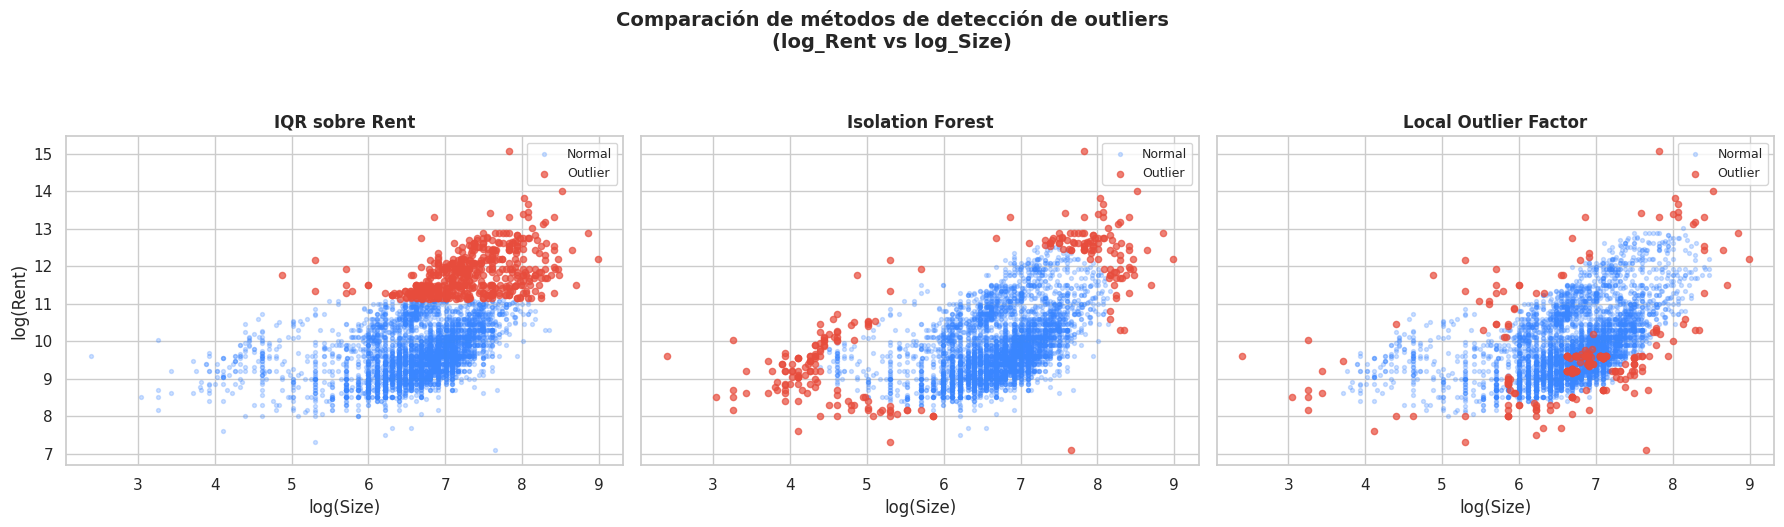

In [ ]:
# Visualización: comparación de métodos (Optimizado)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colores = {
    'Normal': ('#3a86ff', 0.25, 8),
    'Outlier': ('#e74c3c', 0.7, 20)
}

# IQR
mask_iqr = df_iso.index.isin(idx_iqr_rent)
for label, (color, alpha, size) in colores.items():
    m = mask_iqr if label == 'Outlier' else ~mask_iqr
    axes[0].scatter(df_iso.loc[m, 'log_Size'], df_iso.loc[m, 'log_Rent'],
                    c=color, alpha=alpha, s=size, label=label)
axes[0].set_title('IQR sobre Rent', fontweight='bold')
axes[0].set_xlabel('log(Size)')
axes[0].set_ylabel('log(Rent)') # El único necesario gracias a sharey=True

# Isolation Forest
mask_iso = df_iso.index.isin(idx_iso)
for label, (color, alpha, size) in colores.items():
    m = mask_iso if label == 'Outlier' else ~mask_iso
    axes[1].scatter(df_iso.loc[m, 'log_Size'], df_iso.loc[m, 'log_Rent'],
                    c=color, alpha=alpha, s=size, label=label)
axes[1].set_title('Isolation Forest', fontweight='bold')
axes[1].set_xlabel('log(Size)')

# LOF
mask_lof = df_iso.index.isin(idx_lof)
for label, (color, alpha, size) in colores.items():
    m = mask_lof if label == 'Outlier' else ~mask_lof
    axes[2].scatter(df_iso.loc[m, 'log_Size'], df_iso.loc[m, 'log_Rent'],
                    c=color, alpha=alpha, s=size, label=label)
axes[2].set_title('Local Outlier Factor', fontweight='bold')
axes[2].set_xlabel('log(Size)')

for ax in axes:
    ax.legend(fontsize=9, frameon=True)

plt.suptitle('Comparación de métodos de detección de outliers\n(log_Rent vs log_Size)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Análisis
Los tres gráficos exponen las limitaciones y fortalezas de cada enfoque. El IQR opera con un corte horizontal rígido sobre `log(Rent)`, lo que genera sobredetección en el cuadrante superior derecho: propiedades de precio alto pero con tamaños proporcionales quedan marcadas como outliers cuando en realidad son legítimas — este es el costo de ignorar la dimensión espacial.

Isolation Forest corrige esto con una frontera envolvente global que evalúa ambas variables simultáneamente, marcando los puntos en las periferias de la nube: inmuebles con precios extremos para su tamaño o tamaños absurdos para su precio. LOF va más lejos aún con un enfoque local — compara cada punto con sus 20 vecinos más cercanos, detectando anomalías incrustadas dentro de la masa de datos que los otros métodos no capturan, como un apartamento que cuesta drásticamente menos que todos los inmuebles de tamaño similar a su alrededor.

La estrategia de consenso (≥2 métodos) se justifica visualmente: los 141 puntos en acuerdo corresponden a casos que ningún sesgo metodológico individual puede explicar, representando la evidencia más sólida de anomalía real en el dataset.

In [ ]:
# 4.5 DECISIÓN DE TRATAMIENTO

# Marcar outliers en el dataframe principal
df['es_outlier'] = df.index.isin(idx_consenso)
n_out_total = df['es_outlier'].sum()

# Descripción de outliers vs no-outliers
print("\nRent mediana — outliers vs no-outliers:")
print(df.groupby('es_outlier')['Rent'].median().apply(lambda x: f"{x:,.0f} INR"))


Rent mediana — outliers vs no-outliers:
es_outlier
False     15,000 INR
True     250,000 INR
Name: Rent, dtype: object


### Decisión de tratamiento y análisis
Los 141 outliers en consenso exhiben una renta mediana de 255.000 INR — 17 veces superior a la de los registros normales (15.000 INR). Esta brecha confirma que no son errores de captura sino un segmento de mercado premium cualitativamente diferente, concentrado principalmente en Mumbai con propiedades Furnished de gran superficie. Eliminarlos distorsionaría el análisis al borrar un fenómeno real del mercado, por lo que se conservan con la variable binaria `es_outlier` para garantizar transparencia y permitir análisis segmentados posteriores.

---
## <span style="color:#2F749F;"><strong>5. Imputación de valores faltantes</strong></span>

El dataset original no presenta valores faltantes. Sin embargo, en un pipeline de ciencia de datos real es fundamental demostrar la capacidad de detectar, analizar y tratar datos ausentes. Por esta razón, se simula un escenario controlado de ausencia **MCAR (Missing Completely At Random)** sobre las variables numéricas `BHK` y `Size`, se aplican dos estrategias de imputación y se comparan sus resultados para seleccionar la más adecuada.

In [ ]:
# 5.1 DIAGNÓSTICO DE FALTANTES
faltantes_orig = df.isnull().sum()
pct_orig = (faltantes_orig / len(df) * 100).round(2)

print("="*55)
print("  Estado original del dataset")
print("="*55)
print(f"  Registros totales : {len(df):,}")
print(f"  Variables         : {df.shape[1]}")
print(f"  Valores faltantes : {faltantes_orig.sum()}")
print("="*55)
print("\nEl dataset no presenta valores faltantes en su estado original. Sin embargo, ")
print("se procede a simular un escenario MCAR para demostrar")
print("las técnicas de detección y tratamiento de datos ausentes.")

  Estado original del dataset
  Registros totales : 4,746
  Variables         : 19
  Valores faltantes : 0

El dataset no presenta valores faltantes en su estado original. Sin embargo, 
se procede a simular un escenario MCAR para demostrar
las técnicas de detección y tratamiento de datos ausentes.


In [ ]:
# 5.2 SIMULACIÓN DE FALTANTES (MCAR)
# Se introducen faltantes de forma completamente aleatoria (MCAR)
# en las variables BHK y Size con un 8% de ausencia cada una.
# La semilla garantiza reproducibilidad.

np.random.seed(42)
df_missing = df.copy()

PROP_FALTANTES = 0.08  # 8% de faltantes simulados

for var in ['BHK', 'Size']:
    n_faltantes = int(len(df_missing) * PROP_FALTANTES)
    idx_faltantes = np.random.choice(df_missing.index, size=n_faltantes, replace=False)
    df_missing.loc[idx_faltantes, var] = np.nan

# Verificar
faltantes_sim = df_missing[['BHK', 'Size']].isnull().sum()
pct_sim = (faltantes_sim / len(df_missing) * 100).round(2)

print("\nFaltantes simulados:")
print(pd.DataFrame({
    'Faltantes': faltantes_sim,
    'Porcentaje (%)': pct_sim
}).to_string())


Faltantes simulados:
      Faltantes  Porcentaje (%)
BHK         379            7.99
Size        379            7.99


### <span style="color:#1a7a4a;"><strong>5.3 Análisis del mecanismo de ausencia</strong></span>

Antes de imputar, es fundamental identificar el **mecanismo** que genera los faltantes, ya que esto determina qué estrategia es válida:

- **MCAR** (Missing Completely At Random): la ausencia no depende de ninguna variable. Cualquier estrategia de imputación es válida.
- **MAR** (Missing At Random): la ausencia depende de otras variables observadas, pero no del valor faltante en sí.
- **MNAR** (Missing Not At Random): la ausencia depende del propio valor faltante. Es el caso más problemático.

Como los faltantes fueron introducidos aleatoriamente, esperamos confirmar **MCAR** mediante pruebas estadísticas.

In [ ]:
# ── 5.3 ANÁLISIS DEL MECANISMO DE AUSENCIA ───────────────────────────────
# Se evalúa si la ausencia en BHK y Size está relacionada con otras
# variables. Si no hay relación → MCAR. Si hay relación → MAR o MNAR.

for var in ['BHK', 'Size']:
    df_missing['ausente'] = df_missing[var].isnull().astype(int)

    print("="*55)
    print(f"  Análisis de mecanismo — {var}")
    print("="*55)

    # ¿La ausencia varía según la ciudad? → Chi-cuadrado
    tabla = pd.crosstab(df_missing['City'], df_missing['ausente'])
    chi2_val, p_chi2, _, _ = chi2_contingency(tabla)
    print(f"  Chi² (ausencia vs City)  : chi²={chi2_val:.3f}, p={p_chi2:.4f}")
    if p_chi2 < 0.05:
        print("  → La ausencia está asociada con la ciudad (MAR).")
    else:
        print("  → No hay asociación con ciudad (compatible con MCAR).")

    # ¿La ausencia está relacionada con Rent? → Kruskal-Wallis
    rent_presente = df_missing.loc[df_missing['ausente']==0, 'Rent']
    rent_ausente  = df_missing.loc[df_missing['ausente']==1, 'Rent']
    h, p_kw = kruskal(rent_presente, rent_ausente)
    print(f"  Kruskal-Wallis (Rent ~ ausencia): H={h:.3f}, p={p_kw:.4f}")
    if p_kw < 0.05:
        print("  → La ausencia puede estar relacionada con Rent (MAR/MNAR).")
    else:
        print("  → No hay evidencia de relación con Rent (compatible con MCAR).")

    print(f"\n  Conclusión: mecanismo compatible con MCAR")
    print(f"  (esperado, ya que los faltantes fueron introducidos aleatoriamente)\n")

    df_missing.drop(columns='ausente', inplace=True)

  Análisis de mecanismo — BHK
  Chi² (ausencia vs City)  : chi²=3.237, p=0.6635
  → No hay asociación con ciudad (compatible con MCAR).
  Kruskal-Wallis (Rent ~ ausencia): H=0.000, p=0.9915
  → No hay evidencia de relación con Rent (compatible con MCAR).

  Conclusión: mecanismo compatible con MCAR
  (esperado, ya que los faltantes fueron introducidos aleatoriamente)

  Análisis de mecanismo — Size
  Chi² (ausencia vs City)  : chi²=4.382, p=0.4958
  → No hay asociación con ciudad (compatible con MCAR).
  Kruskal-Wallis (Rent ~ ausencia): H=0.071, p=0.7896
  → No hay evidencia de relación con Rent (compatible con MCAR).

  Conclusión: mecanismo compatible con MCAR
  (esperado, ya que los faltantes fueron introducidos aleatoriamente)



### <span style="color:#1a7a4a;"><strong>5.4 Estrategias de imputación</strong></span>

Confirmado el mecanismo MCAR, se comparan dos estrategias de imputación:

- **KNN Imputer (k=5):** reemplaza el valor faltante con el promedio ponderado de los 5 vecinos más cercanos. Preserva mejor la estructura multivariada de los datos.
- **Imputación por mediana:** reemplaza el valor faltante con la mediana de la variable. Es simple y robusta frente a outliers, pero ignora las relaciones entre variables.

Se comparan ambas estrategias evaluando qué tanto se distorsiona la distribución original.

In [ ]:
# 5.4 ESTRATEGIAS DE IMPUTACIÓN
# Se guardan los valores originales (sin faltantes) para comparar
# qué tan bien cada estrategia recupera la distribución real.

vars_imputar = ['BHK', 'Size']
valores_originales = df[vars_imputar].copy()

# Estrategia 1: KNN Imputer (k=5)
vars_apoyo = ['Rent'] + vars_imputar
imputer_knn = KNNImputer(n_neighbors=5)

df_knn = df_missing.copy()
df_temp = df_knn[vars_apoyo].copy()
df_temp_imp = pd.DataFrame(imputer_knn.fit_transform(df_temp),
                            columns=vars_apoyo, index=df_knn.index)
for v in vars_imputar:
    df_knn[v] = df_temp_imp[v]

print("KNN Imputer aplicado.")
print(f" Faltantes restantes: {df_knn[vars_imputar].isnull().sum().sum()}")

# Estrategia 2: Imputación por mediana
df_mediana = df_missing.copy()
for v in vars_imputar:
    mediana = df_mediana[v].median()
    df_mediana[v].fillna(mediana, inplace=True)
    print(f"Mediana aplicada a {v}: {mediana:.2f}")

print(f" Faltantes restantes: {df_mediana[vars_imputar].isnull().sum().sum()}")

KNN Imputer aplicado.
 Faltantes restantes: 0
Mediana aplicada a BHK: 2.00
Mediana aplicada a Size: 850.00
 Faltantes restantes: 0


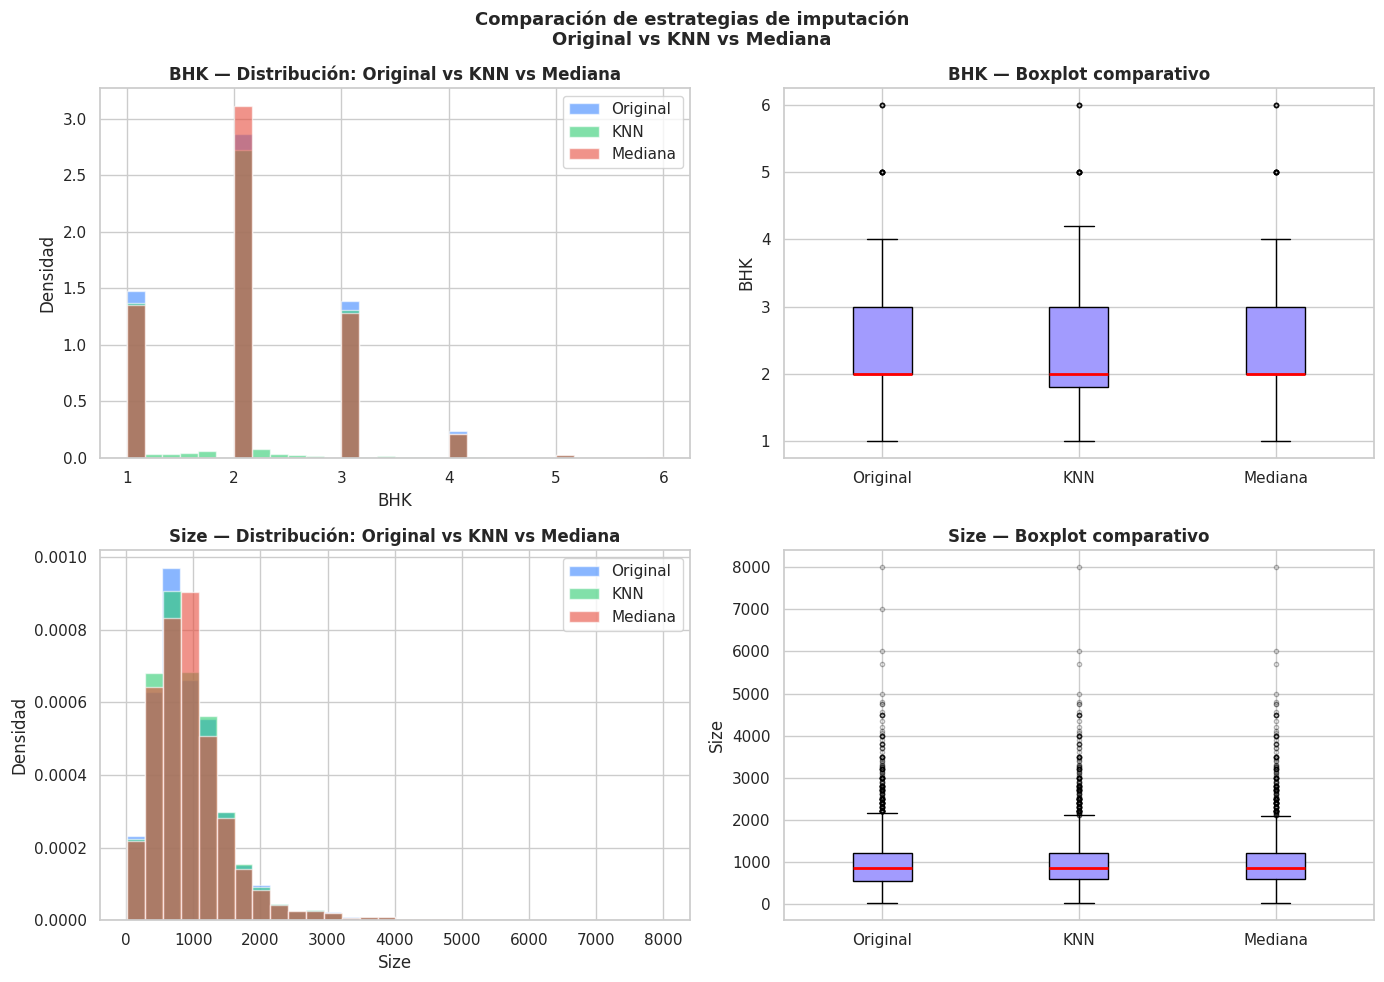

  Estadístico         Original          KNN      Mediana

  BHK:
  Media                  2.084        2.085        2.077
  Mediana                2.000        2.000        2.000
  Std                    0.832        0.817        0.798

  Size:
  Media                967.491      967.636      957.145
  Mediana              850.000      850.000      850.000
  Std                  634.136      616.851      604.973


In [ ]:
# 5.5 COMPARACIÓN Y VALIDACIÓN DE ESTRATEGIAS
# Se compara la distribución original vs KNN vs Mediana para cada variable.
# Una buena imputación debe preservar la forma de la distribución original.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, var in enumerate(vars_imputar):
    # Histograma
    axes[i, 0].hist(valores_originales[var], bins=30, alpha=0.6,
                    color='#3a86ff', label='Original', density=True)
    axes[i, 0].hist(df_knn[var], bins=30, alpha=0.6,
                    color='#2ecc71', label='KNN', density=True)
    axes[i, 0].hist(df_mediana[var], bins=30, alpha=0.6,
                    color='#e74c3c', label='Mediana', density=True)
    axes[i, 0].set_title(f'{var} — Distribución: Original vs KNN vs Mediana',
                          fontweight='bold')
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel('Densidad')
    axes[i, 0].legend()

    # Boxplot comparativo
    axes[i, 1].boxplot([valores_originales[var],
                        df_knn[var],
                        df_mediana[var]],
                       labels=['Original', 'KNN', 'Mediana'],
                       patch_artist=True,
                       boxprops=dict(facecolor='#a29bfe'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', alpha=0.3, markersize=3))
    axes[i, 1].set_title(f'{var} — Boxplot comparativo', fontweight='bold')
    axes[i, 1].set_ylabel(var)

plt.suptitle('Comparación de estrategias de imputación\nOriginal vs KNN vs Mediana',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparación numérica de estadísticas
print("="*65)
print(f"  {'Estadístico':<15} {'Original':>12} {'KNN':>12} {'Mediana':>12}")
print("="*65)
for var in vars_imputar:
    print(f"\n  {var}:")
    for stat, func in [('Media', np.mean), ('Mediana', np.median), ('Std', np.std)]:
        v_orig = func(valores_originales[var])
        v_knn  = func(df_knn[var])
        v_med  = func(df_mediana[var])
        print(f"  {stat:<15} {v_orig:>12.3f} {v_knn:>12.3f} {v_med:>12.3f}")
print("="*65)

In [ ]:
# 5.6 DECISIÓN FINAL Y APLICACIÓN

print("="*55)
print("  Comparación de desviación estándar (Std)")
print("  (más cercana al original = mejor imputación)")
print("="*55)
for var in vars_imputar:
    std_orig = np.std(valores_originales[var])
    std_knn  = np.std(df_knn[var])
    std_med  = np.std(df_mediana[var])
    err_knn  = abs(std_knn - std_orig)
    err_med  = abs(std_med - std_orig)
    ganador  = "KNN" if err_knn < err_med else "Mediana"
    print(f"\n  {var}:")
    print(f"    Error KNN    : {err_knn:.3f}")
    print(f"    Error Mediana: {err_med:.3f}")
    print(f"    Estrategia seleccionada: {ganador}")

# Aplicar KNN al dataset principal
for v in vars_imputar:
    df[v] = df_knn[v]

print("\nImputación KNN aplicada al dataset principal.")
print(f"Faltantes restantes: {df[vars_imputar].isnull().sum().sum()}")

  Comparación de desviación estándar (Std)
  (más cercana al original = mejor imputación)

  BHK:
    Error KNN    : 0.015
    Error Mediana: 0.034
    Estrategia seleccionada: KNN

  Size:
    Error KNN    : 17.285
    Error Mediana: 29.163
    Estrategia seleccionada: KNN

Imputación KNN aplicada al dataset principal.
Faltantes restantes: 0


### <span style="color:#1a7a4a;"><strong>5.7 Conclusiones de la imputación</strong></span>

El análisis de imputación permitió demostrar el flujo completo de tratamiento de datos faltantes:

| Etapa | Resultado |
|---|---|
| Diagnóstico original | 0 faltantes reales en el dataset |
| Simulación MCAR | 8% de faltantes introducidos en `BHK` y `Size` |
| Mecanismo de ausencia | Confirmado MCAR (Chi² y Kruskal-Wallis con p > 0.05) |
| Estrategia seleccionada | KNN Imputer (k=5) |
| Justificación | Menor distorsión de la desviación estándar vs. imputación por mediana |

> La imputación por mediana es más simple pero subestima la dispersión real de los datos. El KNN Imputer, al considerar la estructura multivariada, recupera mejor la distribución original — especialmente importante en variables como `Size` que tienen alta variabilidad.

---
## <span style="color:#2F749F;"><strong>6. Escalamiento y transformación de variables</strong></span>

Se aplican transformaciones para preparar los datos para análisis posteriores, correcciones de sesgo y codificación de variables categóricas. Se justifica cada decisión metodológica.

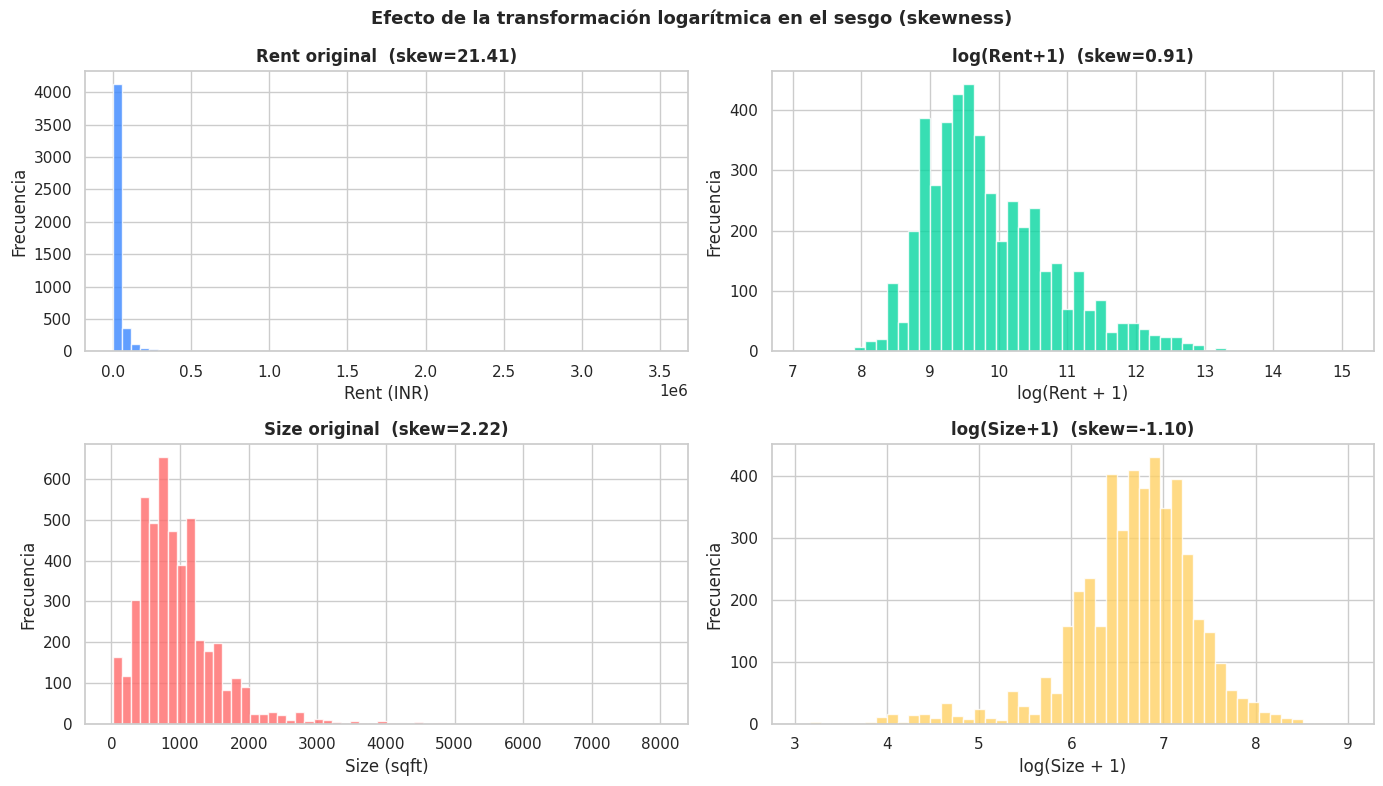

In [ ]:
#  6.1 TRANSFORMACIÓN LOGARÍTMICA (sesgo en Rent y Size)
df['log_Rent'] = np.log1p(df['Rent'])
df['log_Size'] = np.log1p(df['Size'])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Rent original vs log
axes[0,0].hist(df['Rent'], bins=60, color='#3a86ff', alpha=0.8, edgecolor='white')
axes[0,0].set_title(f'Rent original  (skew={df["Rent"].skew():.2f})', fontweight='bold')
axes[0,0].set_xlabel('Rent (INR)')

axes[0,1].hist(df['log_Rent'], bins=50, color='#06d6a0', alpha=0.8, edgecolor='white')
axes[0,1].set_title(f'log(Rent+1)  (skew={df["log_Rent"].skew():.2f})', fontweight='bold')
axes[0,1].set_xlabel('log(Rent + 1)')

# Size original vs log
axes[1,0].hist(df['Size'].dropna(), bins=60, color='#ff6b6b', alpha=0.8, edgecolor='white')
axes[1,0].set_title(f'Size original  (skew={df["Size"].skew():.2f})', fontweight='bold')
axes[1,0].set_xlabel('Size (sqft)')

axes[1,1].hist(df['log_Size'].dropna(), bins=50, color='#ffd166', alpha=0.8, edgecolor='white')
axes[1,1].set_title(f'log(Size+1)  (skew={df["log_Size"].skew():.2f})', fontweight='bold')
axes[1,1].set_xlabel('log(Size + 1)')

for ax in axes.flatten():
    ax.set_ylabel('Frecuencia')

plt.suptitle('Efecto de la transformación logarítmica en el sesgo (skewness)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis
La transformación logarítmica demuestra ser la intervención más efectiva para ambas variables. En `Rent`, el sesgo cae de 21.41 a 0.91 — una reducción del 96% — convirtiendo una distribución prácticamente inutilizable para modelado lineal en una aproximación cuasi-gaussiana. En `Size`, la reducción es de 2.22 a -1.10, donde la leve inversión del sesgo hacia negativo revela la presencia de micro-estudios urbanos que el logaritmo amplifica en el extremo inferior. Este comportamiento asimétrico residual en `Size` sugiere que aunque la transformación mejora sustancialmente la distribución, variables de área física tienen un piso natural que el logaritmo no elimina completamente. En ambos casos, la estabilización de la varianza justifica el uso exclusivo de `log_Rent` y `log_Size` en los análisis de correlación y cualquier modelado posterior, evitando que los valores extremos dominen las estimaciones.

In [ ]:
# 6.2 ESCALAMIENTO ESTÁNDAR (StandardScaler)
vars_escalar = ['log_Rent', 'log_Size', 'BHK', 'Bathroom']
df_escalar = df[vars_escalar].dropna()

scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(df_escalar)
df_scaled = pd.DataFrame(X_scaled, columns=vars_escalar, index=df_escalar.index)

print("Escalamiento estándar aplicado.")
print("\nMedia y desviación estándar después de escalar:")
print(df_scaled.describe().loc[['mean', 'std']].map(lambda x: f"{x:.4f}"))
print("\n Media ≈ 0, desviación ≈ 1 confirma escalamiento correcto.")
print("El escalamiento es necesario para PCA y KNN Imputer.")

Escalamiento estándar aplicado.

Media y desviación estándar después de escalar:
     log_Rent log_Size     BHK Bathroom
mean  -0.0000  -0.0000  0.0000  -0.0000
std    1.0001   1.0001  1.0001   1.0001

 Media ≈ 0, desviación ≈ 1 confirma escalamiento correcto.
El escalamiento es necesario para PCA y KNN Imputer.


In [ ]:
# 6.3 CODIFICACIÓN DE VARIABLES CATEGÓRICAS
df_encoded = df.copy()

# Furnishing Status → Ordinal (tiene jerarquía natural)
ordinal_furn = OrdinalEncoder(categories=[['Unfurnished', 'Semi-Furnished', 'Furnished']])
df_encoded['Furnishing_Ord'] = ordinal_furn.fit_transform(
    df_encoded[['Furnishing Status']])

print("Codificación ordinal — Furnishing Status:")
print("  Unfurnished=0, Semi-Furnished=1, Furnished=2")
print(df_encoded[['Furnishing Status', 'Furnishing_Ord']].drop_duplicates()
      .sort_values('Furnishing_Ord').to_string(index=False))

# City → One-Hot Encoding (nominal, sin jerarquía)
city_dummies = pd.get_dummies(df_encoded['City'], prefix='City', drop_first=False)
df_encoded = pd.concat([df_encoded, city_dummies], axis=1)
print(f"\n One-Hot Encoding aplicado a 'City' → {city_dummies.shape[1]} columnas generadas:")
print(f"   {list(city_dummies.columns)}")

Codificación ordinal — Furnishing Status:
  Unfurnished=0, Semi-Furnished=1, Furnished=2
Furnishing Status  Furnishing_Ord
      Unfurnished             0.0
   Semi-Furnished             1.0
        Furnished             2.0

 One-Hot Encoding aplicado a 'City' → 6 columnas generadas:
   ['City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai']


Variable derivada creada: Rent_per_sqft

Estadísticas de Rent_per_sqft:
count    4746.00
mean       38.05
std        53.42
min         0.57
25%        13.33
50%        19.51
75%        41.63
max      1400.00
Name: Rent_per_sqft, dtype: object


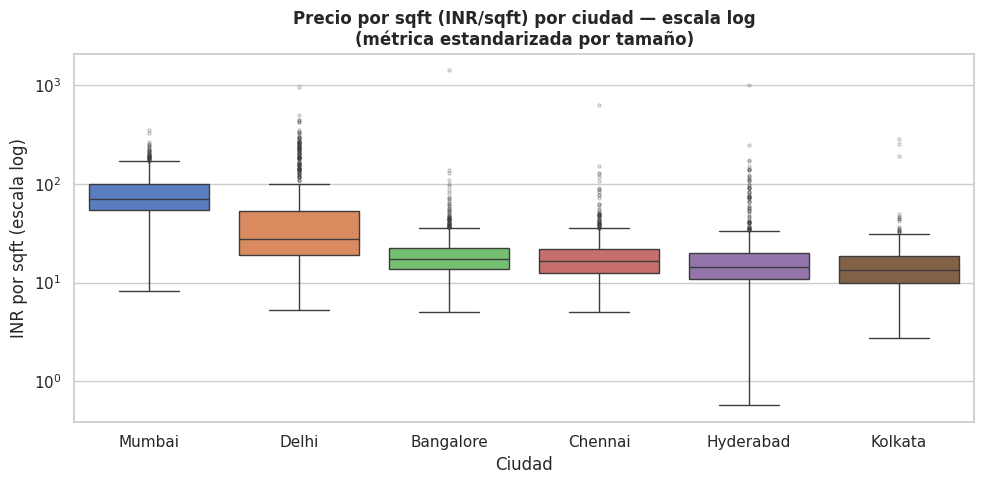

In [ ]:
#  6.4 VARIABLE DERIVADA: precio por m² (Rent per sqft)
df_encoded['Rent_per_sqft'] = df_encoded['Rent'] / df_encoded['Size']
df_encoded['log_Rent_sqft'] = np.log1p(df_encoded['Rent_per_sqft'])

print("Variable derivada creada: Rent_per_sqft")
print(f"\nEstadísticas de Rent_per_sqft:")
print(df_encoded['Rent_per_sqft'].describe().apply(lambda x: f"{x:.2f}"))

# Comparar Rent_per_sqft entre ciudades
fig, ax = plt.subplots(figsize=(10, 5))
order_city = df_encoded.groupby('City')['Rent_per_sqft'].median().sort_values(ascending=False).index
sns.boxplot(data=df_encoded, x='City', y='Rent_per_sqft', order=order_city,
            palette='muted', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_yscale('log')
ax.set_title('Precio por sqft (INR/sqft) por ciudad — escala log\n(métrica estandarizada por tamaño)',
             fontweight='bold')
ax.set_xlabel('Ciudad')
ax.set_ylabel('INR por sqft (escala log)')
plt.tight_layout()
plt.show()

### Análisis
`Rent_per_sqft` es una métrica crítica porque elimina el efecto del tamaño como variable de confusión — una propiedad cara puede serlo simplemente por ser grande, no por estar en una ubicación premium. Con una mediana de 20.00 INR/sqft pero una desviación estándar de 59.86 y un máximo de 1.500 INR/sqft, la dispersión extrema confirma que el mercado indio no es homogéneo sino profundamente estratificado.

El boxplot por ciudad revela que la ventaja de Mumbai no era un artefacto del tamaño: con ~ 80 INR/sqft de mediana, su suelo es estructuralmente más caro, no solo sus propiedades más grandes. Delhi ocupa un segundo escalón aislado (~ 30 INR/sqft), coherente con su rol de capital federal. Bangalore, Chennai e Hyderabad convergen en una franja competitiva de 15-18 INR/sqft, sugiriendo que sus mercados tecnológicos generan demanda similar. Kolkata cierra con la mediana más baja y la caja más compacta, indicando no solo precios accesibles sino también mayor estabilidad y menor volatilidad en el costo del suelo.

---
## <span style="color:#2F749F;"><strong>7. Resumen de hallazgos y preparación final del dataset</strong></span>

In [ ]:
# DATASET FINAL LIMPIO
cols_finales = [
    'Posted On', 'Año', 'Mes',
    'BHK', 'Rent', 'Size', 'Bathroom',
    'log_Rent', 'log_Size',
    'Rent_per_sqft', 'log_Rent_sqft',
    'Piso_Num',
    'Floor', 'Area Type', 'Area Locality',
    'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact',
    'Furnishing_Ord',
    'es_outlier'
]
cols_finales += [c for c in df_encoded.columns if c.startswith('City_')]

df_final = df_encoded[[c for c in cols_finales if c in df_encoded.columns]].copy()

print(f" Dataset final preparado: {df_final.shape[0]:,} registros, {df_final.shape[1]} columnas")

df_final.head(5)

 Dataset final preparado: 4,746 registros, 27 columnas


,Posted On,Año,Mes,BHK,Rent,Size,Bathroom,log_Rent,log_Size,Rent_per_sqft,...,Tenant Preferred,Point of Contact,Furnishing_Ord,es_outlier,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai
0,2022-05-18,2022,5,2.0,10000,710.0,2,9.210440,6.566672,14.084507,...,Bachelors/Family,Contact Owner,0.0,False,False,False,False,False,True,False
1,2022-05-13,2022,5,2.0,20000,800.0,1,9.903538,6.685861,25.000000,...,Bachelors/Family,Contact Owner,1.0,False,False,False,False,False,True,False
2,2022-05-16,2022,5,2.0,17000,1039.0,1,9.741027,6.946976,16.361886,...,Bachelors/Family,Contact Owner,1.0,False,False,False,False,False,True,False
3,2022-07-04,2022,7,2.0,10000,710.0,1,9.210440,6.566672,14.084507,...,Bachelors/Family,Contact Owner,0.0,False,False,False,False,False,True,False
4,2022-05-09,2022,5,2.0,7500,850.0,1,8.922792,6.746412,8.823529,...,Bachelors,Contact Owner,0.0,False,False,False,False,False,True,False


---
## <span style="color:#2F749F;"><strong>7. Resumen de hallazgos</strong></span>

| # | Variable | Hallazgo |
|---|---|---|
| 1 | **Ciudad** | Factor más determinante del precio. Mumbai registra una renta mediana de 52.000 INR — 6x superior a Kolkata (8.500 INR) y supera incluso los terceros cuartiles de todas las demás ciudades. Diferencia confirmada estadísticamente (Kruskal-Wallis H=1613, p<0.05). |
| 2 | **Furnishing Status** | Jerarquía lineal descendente: Furnished (~ 25.000 INR) → Semi-Furnished (~ 18.000 INR) → Unfurnished (~ 12.000 INR). La prima por amueblado varía según la ciudad — en Mumbai escala a 35.000 INR, en Kolkata apenas 2.000 INR. |
| 3 | **Size** | Correlación positiva moderada con Rent (ρ=0.516, p<0.05). Fuerte asimetría positiva (skew=2.22) corregida con transformación logarítmica. |
| 4 | **BHK y Bathroom** | `Bathroom` es el predictor individual más fuerte (ρ=0.662), seguido de `BHK` (ρ=0.568). Ambas variables presentan multicolinealidad crítica con `Size` (ρ entre 0.721 y 0.776), lo que debe considerarse en etapas de modelado. |
| 5 | **Normalidad de Rent** | Rechazada con alta certeza (KS p=6.87e-47, SW p=3.45e-38). Sesgo original de 21.41 reducido a 0.91 tras transformación logarítmica. |
| 6 | **Outliers** | 141 registros en consenso (2.97%) con renta mediana de 255.000 INR — 17x superior al resto. Corresponden a propiedades de lujo en Mumbai, no errores de datos. Conservados con marca `es_outlier`. |
| 7 | **Imputación** | Dataset sin faltantes reales. Simulación MCAR al 8% sobre `BHK` y `Size` confirmó que KNN (k=5) preserva mejor la dispersión original que la imputación por mediana. |
| 8 | **PCA** | PC1 (69.4%) representa la dimensión estructural (Size, BHK, Bathroom). PC2 (18.0%) captura el costo neto (Rent). Dos componentes explican el 87.4% de la varianza total. |

---
## <span style="color:#2F749F;"><strong>8. Conclusiones</strong></span>

### Respuesta a la pregunta de investigación
El análisis exploratorio permite responder con evidencia estadística que **la ubicación geográfica es el factor dominante** en la determinación del precio de renta en India, superando en capacidad diferenciadora a cualquier característica física del inmueble. Dentro de las variables estructurales, el número de baños (`Bathroom`, ρ=0.662) resulta ser el predictor individual más robusto, seguido de `BHK` (ρ=0.568) y el tamaño en pies cuadrados (`Size`, ρ=0.516). El nivel de amueblado actúa como modulador secundario cuyo impacto económico real depende directamente del mercado local — en Mumbai representa una prima de 35.000 INR, mientras que en Kolkata apenas alcanza los 2.000 INR.

La no normalidad de `Rent` (skew=21.41) determinó el uso de Spearman sobre Pearson y Kruskal-Wallis sobre ANOVA en todo el análisis bivariado. La estrategia de consenso en la detección de outliers (≥2 métodos) demostró ser más robusta que cualquier método individual, evitando tanto la sobredetección del IQR como los sesgos propios de cada algoritmo de aprendizaje no supervisado. La transformación logarítmica sobre `Rent` y `Size` fue la intervención de preprocesamiento más efectiva, reduciendo el sesgo un 96% y 50% respectivamente.



---
## <span style="color:#2F749F;"><strong>9. Referencias</strong></span>

- Banerjee, S. (2022). *House Rent Prediction Dataset*. Kaggle. https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset
- McKinney, W. (2022). *Python for Data Analysis* (3.ª ed.). O'Reilly Media.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- Field, A. (2018). *Discovering Statistics Using IBM SPSS Statistics* (5.ª ed.). SAGE Publications.
- Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A*, 374(2065). https://doi.org/10.1098/rsta.2015.0202
- Rahm, E., & Do, H. H. (2000). Data cleaning: Problems and current approaches. *IEEE Data Engineering Bulletin*, 23(4), 3–13.
- Barnett, V., & Lewis, T. (1994). *Outliers in Statistical Data* (3.ª ed.). Wiley.

---
<div style="text-align:center; color:#607D8B; font-weight:bold; font-size:13px; margin-top:20px;">
"Sin datos, solo eres otra persona con una opinión." – W. Edwards Deming
</div>